# AE Comparison - Reconstruction vs Forecasting (Kuka anomaly detection)

Side-by-side evaluation of two AE *objectives* on the **same data, same architecture, same training budget**:

1. **Reconstruction AE**: input = window, target = window (classical AE baseline).
2. **Forecasting AE**: input = first 64 timesteps, target = next 64 (predict-next objective).

The only thing that changes is the training target. Everything else (data, splits, scaler, model, optimizer, epochs, patience, scoring rule, threshold rule, evaluation set) is held constant so any performance difference is attributable to the objective.

**Anomaly score**: `mean_MSE` per window - average squared error between the model's output and its target.

**Threshold rule (label-free)**: `mu + 2sigma` of `val_normal` scores. We also report ROC-AUC and PR-AUC (threshold-free). All models additionally report a semi-supervised percentile threshold selected on `val_normal + slow_val` and then frozen for `test_normal + slow_test`.

**Final section**: side-by-side comparison table + bar chart.


## 1. Imports & config

In [1]:
import copy
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import (
    average_precision_score, classification_report, confusion_matrix,
    precision_recall_curve, roc_auc_score, roc_curve,
)

torch.manual_seed(42); np.random.seed(42)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

DATA_FOLDER = Path.cwd()
OUTPUT_DIR  = Path.cwd() / "outputs" / "ae_compare" / "semi_supervised"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Data / window
WINDOW_LEN     = 128
STRIDE_TRAIN   = 32
STRIDE_EVAL    = 128
TRAIN_FRAC     = 0.70
VAL_FRAC       = 0.15
SLOW_VAL_FRAC  = 0.50                  # slow_val chooses thresholds; slow_test is final eval
PERCENTILE_CANDIDATES = (80, 85, 90, 95, 97, 99)
FORECAST_HALF  = WINDOW_LEN // 2       # 64 input / 64 target

# Model / training (identical for both AEs)
ENC_CHANNELS   = (64, 32)
BATCH_SIZE     = 256
EPOCHS         = 60
LEARNING_RATE  = 1e-3
PATIENCE       = 10
GRAD_CLIP      = 1.0
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("device :", DEVICE)
print("PyTorch:", torch.__version__)


device : cuda
PyTorch: 2.5.1+cu121


## 2. Data pipeline (shared)

Load -> drop `action` column -> time-aware split normal data (70/15/15) -> split slow data into `slow_val` and `slow_test` -> min-max scaling to `[-1, 1]` with clipping -> sliding windows `(N, F, L)`.

`slow_val` is used only when a labeled threshold must be selected. Final reported test metrics use `test_normal + slow_test`.

We then build **two parallel tensor sets** from the same windows:

- **Reconstruction**: `(input, target) = (W, W)` - predict the window from itself.
- **Forecasting**: `(input, target) = (W[:, :, :64], W[:, :, 64:128])` - predict the next 64 timesteps from the first 64.

Same normal/slow test windows - same evaluation set - fair comparison.


In [2]:
# --- load + drop action -------------------------------------------------
kuka_normal = np.load(DATA_FOLDER / "KukaNormal.npy").astype(np.float32)
kuka_slow   = np.load(DATA_FOLDER / "KukaSlow.npy").astype(np.float32)

X_normal = kuka_normal[:, 1:]                  # drop column 0 ("action")
X_slow   = kuka_slow[:, :-1][:, 1:]            # drop "anomaly" label, drop "action"
n_features = X_normal.shape[1]
print(f"X_normal: {X_normal.shape}   X_slow: {X_slow.shape}   n_features: {n_features}")

# --- time-aware split on normal -----------------------------------------
T = X_normal.shape[0]
nt = int(T * TRAIN_FRAC); nv = int(T * VAL_FRAC)
train_raw = X_normal[:nt]
val_raw   = X_normal[nt:nt + nv]
test_raw  = X_normal[nt + nv:]
print(f"normal raw   train: {train_raw.shape}   val: {val_raw.shape}   test: {test_raw.shape}")

# --- min-max [-1, 1] with clip ------------------------------------------
def fit_minmax(X, feature_range=(-1.0, 1.0), eps=1e-8):
    mn = X.min(axis=0).astype(np.float32)
    mx = X.max(axis=0).astype(np.float32)
    span = np.maximum(mx - mn, eps)
    lo, hi = feature_range
    a = ((hi - lo) / span).astype(np.float32)
    b = (lo - mn * a).astype(np.float32)
    return a, b

def apply_minmax(X, a, b, fr=(-1.0, 1.0)):
    return np.clip(X * a + b, fr[0], fr[1]).astype(np.float32)

a, b = fit_minmax(train_raw)
train_s = apply_minmax(train_raw, a, b)
val_s   = apply_minmax(val_raw,   a, b)
test_s  = apply_minmax(test_raw,  a, b)
slow_s  = apply_minmax(X_slow,    a, b)

# --- sliding windows (N, F, L) ------------------------------------------
def make_windows(x, window_len, stride):
    T = x.shape[0]
    n = (T - window_len) // stride + 1
    idx = np.arange(window_len)[None, :] + stride * np.arange(n)[:, None]
    return np.transpose(x[idx], (0, 2, 1)).astype(np.float32)        # (N, F, L)

W_train = torch.from_numpy(make_windows(train_s, WINDOW_LEN, STRIDE_TRAIN))
W_val   = torch.from_numpy(make_windows(val_s,   WINDOW_LEN, STRIDE_EVAL))
W_test  = torch.from_numpy(make_windows(test_s,  WINDOW_LEN, STRIDE_EVAL))

W_slow_all = torch.from_numpy(make_windows(slow_s, WINDOW_LEN, STRIDE_EVAL))
n_slow_val = int(len(W_slow_all) * SLOW_VAL_FRAC)
W_slow_val = W_slow_all[:n_slow_val].contiguous()
W_slow_test = W_slow_all[n_slow_val:].contiguous()

# Compatibility alias: existing evaluation cells treat W_slow as the untouched slow-test set.
W_slow = W_slow_test

print(f"\nwindows  train={tuple(W_train.shape)}  val_normal={tuple(W_val.shape)}  "
      f"test_normal={tuple(W_test.shape)}  slow_val={tuple(W_slow_val.shape)}  "
      f"slow_test={tuple(W_slow_test.shape)}")

# --- forecast pairs: first 64 = input, next 64 = target -----------------
def split_pair(X_BFL, h):
    return X_BFL[:, :, :h].contiguous(), X_BFL[:, :, h:h * 2].contiguous()

X_train_in, X_train_tg = split_pair(W_train, FORECAST_HALF)
X_val_in,   X_val_tg   = split_pair(W_val,   FORECAST_HALF)
X_test_in,  X_test_tg  = split_pair(W_test,  FORECAST_HALF)
X_slow_val_in,  X_slow_val_tg  = split_pair(W_slow_val,  FORECAST_HALF)
X_slow_test_in, X_slow_test_tg = split_pair(W_slow_test, FORECAST_HALF)

# Compatibility aliases: existing forecasting eval cells use the untouched slow-test set.
X_slow_in, X_slow_tg = X_slow_test_in, X_slow_test_tg

# --- DataLoaders: input/target pairs (recon uses W,W ; forecast uses in,tg)
recon_train_loader = DataLoader(
    TensorDataset(W_train, W_train), batch_size=BATCH_SIZE, shuffle=True)
recon_val_loader   = DataLoader(
    TensorDataset(W_val,   W_val),   batch_size=BATCH_SIZE, shuffle=False)

forecast_train_loader = DataLoader(
    TensorDataset(X_train_in, X_train_tg), batch_size=BATCH_SIZE, shuffle=True)
forecast_val_loader   = DataLoader(
    TensorDataset(X_val_in,   X_val_tg),   batch_size=BATCH_SIZE, shuffle=False)

print(f"forecast pairs   in/target each = {tuple(X_train_in.shape)} (train)")


X_normal: (233792, 85)   X_slow: (41538, 85)   n_features: 85
normal raw   train: (163654, 85)   val: (35068, 85)   test: (35070, 85)

windows  train=(5111, 85, 128)  val_normal=(273, 85, 128)  test_normal=(273, 85, 128)  slow_val=(162, 85, 128)  slow_test=(162, 85, 128)
forecast pairs   in/target each = (5111, 85, 64) (train)


## 3. Shared model & training helper

The same `ConvAE1D` (2-block, channels `64 -> 32`, `tanh` output) is used for both AEs. The training helper takes any `(input, target)` loader and runs an identical training loop - so the only thing that differs between the two AEs is *what data is fed in*.

In [3]:
class ConvAE1D(nn.Module):
    def __init__(self, n_features, enc_channels=(64, 32)):
        super().__init__()
        c1, c2 = enc_channels
        self.encoder = nn.Sequential(
            nn.Conv1d(n_features, c1, 3, padding=1), nn.ReLU(inplace=True), nn.MaxPool1d(2),
            nn.Conv1d(c1, c2, 3, padding=1),         nn.ReLU(inplace=True), nn.MaxPool1d(2),
        )
        self.decoder = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv1d(c2, c2, 3, padding=1), nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv1d(c2, c1, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv1d(c1, n_features, 3, padding=1),
            nn.Tanh(),
        )

    def encode(self, x): return self.encoder(x)
    def decode(self, z): return self.decoder(z)
    def forward(self, x): return self.decode(self.encode(x))


def run_epoch(model, loader, loss_fn, device, optimizer=None, grad_clip=None):
    is_train = optimizer is not None
    model.train(is_train)
    total, n = 0.0, 0
    for xi, xt in loader:
        xi = xi.to(device, non_blocking=True)
        xt = xt.to(device, non_blocking=True)
        loss = loss_fn(model(xi), xt)
        if is_train:
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            if grad_clip is not None:
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()
        total += loss.item() * xi.size(0); n += xi.size(0)
    return total / max(n, 1)


def train_model(train_loader, val_loader, *, tag, seed=42):
    """Build a fresh ConvAE1D, train with early stopping. Returns (model, train_losses, val_losses, best_val)."""
    torch.manual_seed(seed); np.random.seed(seed)
    model = ConvAE1D(n_features=n_features, enc_channels=ENC_CHANNELS).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    loss_fn   = nn.MSELoss()
    n_params  = sum(p.numel() for p in model.parameters())
    print(f"[{tag}] ConvAE1D  params={n_params:,}  enc={ENC_CHANNELS}")

    train_losses, val_losses = [], []
    best_val, best_state, remaining = float("inf"), None, PATIENCE
    for epoch in range(1, EPOCHS + 1):
        tr = run_epoch(model, train_loader, loss_fn, DEVICE, optimizer, GRAD_CLIP)
        with torch.no_grad():
            va = run_epoch(model, val_loader, loss_fn, DEVICE, optimizer=None)
        train_losses.append(tr); val_losses.append(va)
        improved = va < best_val - 1e-6
        if improved:
            best_val = va
            best_state = copy.deepcopy(model.state_dict())
            remaining = PATIENCE
        print(f"  [{tag}] epoch {epoch:03d} | train {tr:.6f} | val {va:.6f}{' *' if improved else ''}")
        if not improved:
            remaining -= 1
            if remaining <= 0:
                print(f"  [{tag}] Early stop at epoch {epoch} (best val {best_val:.6f})")
                break

    model.load_state_dict(best_state)
    return model, train_losses, val_losses, best_val


@torch.no_grad()
def score_mean_mse(model, x_in, x_tg, batch_size=256, device=DEVICE):
    """One scalar per window: average squared error between model(x_in) and x_tg."""
    model.eval()
    out = []
    for i in range(0, x_in.shape[0], batch_size):
        xi = x_in[i:i + batch_size].to(device)
        xt = x_tg[i:i + batch_size].to(device)
        out.append((model(xi) - xt).pow(2).mean(dim=(1, 2)).cpu().numpy())
    return np.concatenate(out)


def _binary_metrics_at_threshold(y, s, thr):
    pred = (s > thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    P = tp / max(tp + fp, 1)
    R = tp / max(tp + fn, 1)
    F1 = 2 * P * R / max(P + R, 1e-12) if (P + R) > 0 else 0.0
    return {
        "P": float(P), "R": float(R), "F1": float(F1),
        "tp": int(tp), "fp": int(fp), "tn": int(tn), "fn": int(fn),
    }


def select_percentile_threshold_from_val(sv, ss_val, st, ss_test, *, tag,
                                         percentiles=PERCENTILE_CANDIDATES):
    """Choose a percentile threshold on val_normal + slow_val, then freeze it for test."""
    y_val = np.concatenate([np.zeros(sv.size, np.int64), np.ones(ss_val.size, np.int64)])
    s_val = np.concatenate([sv, ss_val])
    y_test = np.concatenate([np.zeros(st.size, np.int64), np.ones(ss_test.size, np.int64)])
    s_test = np.concatenate([st, ss_test])

    rows = []
    for p in percentiles:
        name = f"p{p:g}"
        thr = float(np.percentile(sv, p))
        val = _binary_metrics_at_threshold(y_val, s_val, thr)
        test = _binary_metrics_at_threshold(y_test, s_test, thr)
        row = {"model": tag, "rule": name, "percentile": float(p), "thr": float(thr)}
        row.update({f"val_{k}": v for k, v in val.items()})
        row.update({f"test_{k}": v for k, v in test.items()})
        row.update(test)  # final test metrics at this frozen threshold
        rows.append(row)

    best = max(rows, key=lambda r: (r["val_F1"], r["val_R"], -r["val_fp"], r["percentile"]))
    return rows, best


def attach_percentile_selection(res, ss_val, *, display_name=None):
    tag = display_name or res["tag"]
    rows, best = select_percentile_threshold_from_val(
        res["sv"], ss_val, res["st"], res["ss"], tag=tag)
    res["percentile_rows"] = rows
    res["best_percentile"] = best
    return res


def plot_metric_bars(labels, roc, pr, f1_mu2, f1_pct, pct_rules, *, title,
                     selected_label="F1 @ selected percentile", figsize=(9, 4.4),
                     ax=None, legend=True, show=True, ylim_top=1.16):
    """Clean grouped headline chart with labels/legend kept away from the bars."""
    created_fig = ax is None
    if created_fig:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    x = np.arange(len(labels))
    w = 0.18
    bars = [
        ax.bar(x - 1.5 * w, roc, width=w, label="ROC-AUC"),
        ax.bar(x - 0.5 * w, pr, width=w, label="PR-AUC"),
        ax.bar(x + 0.5 * w, f1_mu2, width=w, label="F1 @ mu+2sigma"),
        ax.bar(x + 1.5 * w, f1_pct, width=w, label=selected_label),
    ]
    bar_text = [
        [f"{v:.2f}" for v in roc],
        [f"{v:.2f}" for v in pr],
        [f"{v:.2f}" for v in f1_mu2],
        [f"{v:.2f}\n{rule}" for v, rule in zip(f1_pct, pct_rules)],
    ]
    for container, texts in zip(bars, bar_text):
        labels_added = ax.bar_label(container, labels=texts, padding=3, fontsize=8)
        for text in labels_added:
            text.set_clip_on(False)

    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylim(0.0, ylim_top)
    ax.set_ylabel("score")
    ax.set_title(title, pad=12)
    ax.grid(True, axis="y", alpha=0.28)
    ax.margins(x=0.08)

    if legend:
        ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.14),
                  ncol=2, fontsize=8, frameon=True)
    if created_fig and show:
        fig.tight_layout(rect=(0, 0.12, 1, 1))
        plt.show()
    return fig, ax


def evaluate_scores(sv, st, ss, *, tag):
    """Given val_normal / test_normal / slow scores, return a dict with ROC, PR, threshold, CM, F1 panel."""
    y_eval = np.concatenate([np.zeros(st.size, np.int64), np.ones(ss.size, np.int64)])
    s_eval = np.concatenate([st, ss])

    roc_auc = float(roc_auc_score(y_eval, s_eval))
    pr_auc  = float(average_precision_score(y_eval, s_eval))

    rules = {"mu+2sigma": float(sv.mean() + 2.0 * sv.std())}
    rules.update({f"p{p:g}": float(np.percentile(sv, p)) for p in PERCENTILE_CANDIDATES})
    panel = {}
    for name, thr in rules.items():
        panel[name] = {"thr": float(thr), **_binary_metrics_at_threshold(y_eval, s_eval, thr)}

    headline = panel["mu+2sigma"]
    return {
        "tag": tag,
        "roc_auc": roc_auc,
        "pr_auc":  pr_auc,
        "threshold": headline["thr"],
        "operating_points": panel,
        "y_eval": y_eval, "s_eval": s_eval,
        "sv": sv, "st": st, "ss": ss,
    }


def print_headline(res):
    y, s, thr = res["y_eval"], res["s_eval"], res["threshold"]
    pred = (s > thr).astype(int)
    cm = confusion_matrix(y, pred, labels=[0, 1])
    print(f"[{res['tag']}]  ROC-AUC = {res['roc_auc']:.4f}   PR-AUC = {res['pr_auc']:.4f}")
    print(f"[{res['tag']}]  Threshold (val_normal mu+2sigma) = {thr:.6f}")
    print()
    print(f"               pred normal | pred anomaly")
    print(f"actual normal      {cm[0,0]:5d}        {cm[0,1]:5d}")
    print(f"actual anomaly     {cm[1,0]:5d}        {cm[1,1]:5d}")
    print()
    print(classification_report(y, pred, target_names=["normal", "anomaly"], digits=3))


def plot_diagnostics(res, score_label):
    y, s, thr = res["y_eval"], res["s_eval"], res["threshold"]
    st, ss = res["st"], res["ss"]
    pred = (s > thr).astype(int)
    cm = confusion_matrix(y, pred, labels=[0, 1])

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f"{res['tag']}  |  ROC={res['roc_auc']:.3f}  PR={res['pr_auc']:.3f}", y=1.02)

    ax = axes[0]
    ax.hist(st, bins=60, alpha=0.55, density=True, label="normal (test)")
    ax.hist(ss, bins=60, alpha=0.55, density=True, label="anomalous (slow)")
    ax.axvline(thr, color="red", linestyle="--", label=f"thr (mu+2sigma)={thr:.4f}")
    ax.set_yscale("log")
    ax.set_xlabel(score_label); ax.set_ylabel("density")
    ax.set_title("Score distribution"); ax.legend(fontsize=8)

    ax = axes[1]
    fpr, tpr, _ = roc_curve(y, s)
    prec, rec, _ = precision_recall_curve(y, s)
    ax.plot(fpr, tpr, label=f"ROC (AUC={res['roc_auc']:.3f})")
    ax.plot(rec, prec, label=f"PR  (AUC={res['pr_auc']:.3f})", linestyle="--")
    ax.plot([0, 1], [0, 1], "k:", alpha=0.4)
    ax.set_xlabel("FPR / Recall"); ax.set_ylabel("TPR / Precision")
    ax.set_title("ROC + PR curves"); ax.legend(fontsize=8)

    ax = axes[2]
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["pred normal", "pred anomaly"])
    ax.set_yticklabels(["actual normal", "actual anomaly"])
    for (i, j), v in np.ndenumerate(cm):
        ax.text(j, i, str(v), ha="center", va="center",
                color="white" if v > cm.max() / 2 else "black", fontsize=12)
    ax.set_title("Confusion matrix")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout(); plt.show()


print("helpers ready")

helpers ready


## 4. Reconstruction AE - the classical baseline

Input = window, target = same window. The model learns to *compress and reconstruct* normal behaviour. Anomalies are detected as windows the AE cannot reconstruct well.

[recon AE] ConvAE1D  params=48,277  enc=(64, 32)
  [recon AE] epoch 001 | train 0.174711 | val 0.118908 *
  [recon AE] epoch 002 | train 0.105636 | val 0.103597 *
  [recon AE] epoch 003 | train 0.078272 | val 0.085670 *
  [recon AE] epoch 004 | train 0.056879 | val 0.070867 *
  [recon AE] epoch 005 | train 0.043149 | val 0.061866 *
  [recon AE] epoch 006 | train 0.033365 | val 0.052610 *
  [recon AE] epoch 007 | train 0.026105 | val 0.044943 *
  [recon AE] epoch 008 | train 0.022726 | val 0.042294 *
  [recon AE] epoch 009 | train 0.021409 | val 0.039967 *
  [recon AE] epoch 010 | train 0.020213 | val 0.038049 *
  [recon AE] epoch 011 | train 0.019006 | val 0.035505 *
  [recon AE] epoch 012 | train 0.018273 | val 0.034704 *
  [recon AE] epoch 013 | train 0.017270 | val 0.033373 *
  [recon AE] epoch 014 | train 0.016772 | val 0.032011 *
  [recon AE] epoch 015 | train 0.016071 | val 0.031479 *
  [recon AE] epoch 016 | train 0.015238 | val 0.030621 *
  [recon AE] epoch 017 | train 0.014747

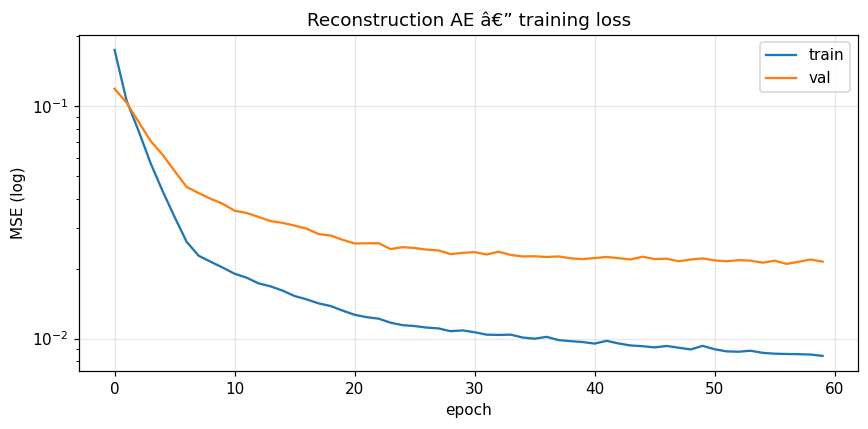

In [4]:
recon_model, recon_tr_losses, recon_va_losses, recon_best_val = train_model(
    recon_train_loader, recon_val_loader, tag="recon AE")

torch.save({"model_state": recon_model.state_dict(),
            "train_losses": recon_tr_losses, "val_losses": recon_va_losses,
            "config": {"window_len": WINDOW_LEN, "objective": "reconstruction",
                       "enc_channels": list(ENC_CHANNELS),
                       "batch_size": BATCH_SIZE, "lr": LEARNING_RATE,
                       "epochs_run": len(recon_tr_losses),
                       "best_val": recon_best_val}},
           OUTPUT_DIR / "recon_ae.pt")
print("saved ->", OUTPUT_DIR / "recon_ae.pt")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(recon_tr_losses, label="train"); ax.plot(recon_va_losses, label="val")
ax.set_yscale("log"); ax.set_xlabel("epoch"); ax.set_ylabel("MSE (log)")
ax.set_title("Reconstruction AE - training loss"); ax.legend()
plt.tight_layout(); plt.show()

val_normal   n= 273  mean=0.02095  p99=0.03440
test_normal  n= 273  mean=0.01685  p99=0.03211
slow_val     n= 162  mean=0.00761  p99=0.01085
slow_test    n= 162  mean=0.03266  p99=0.05112

[Reconstruction AE]  ROC-AUC = 0.8906   PR-AUC = 0.9003
[Reconstruction AE]  Threshold (val_normal mu+2sigma) = 0.033604

               pred normal | pred anomaly
actual normal        273            0
actual anomaly        89           73

              precision    recall  f1-score   support

      normal      0.754     1.000     0.860       273
     anomaly      1.000     0.451     0.621       162

    accuracy                          0.795       435
   macro avg      0.877     0.725     0.741       435
weighted avg      0.846     0.795     0.771       435



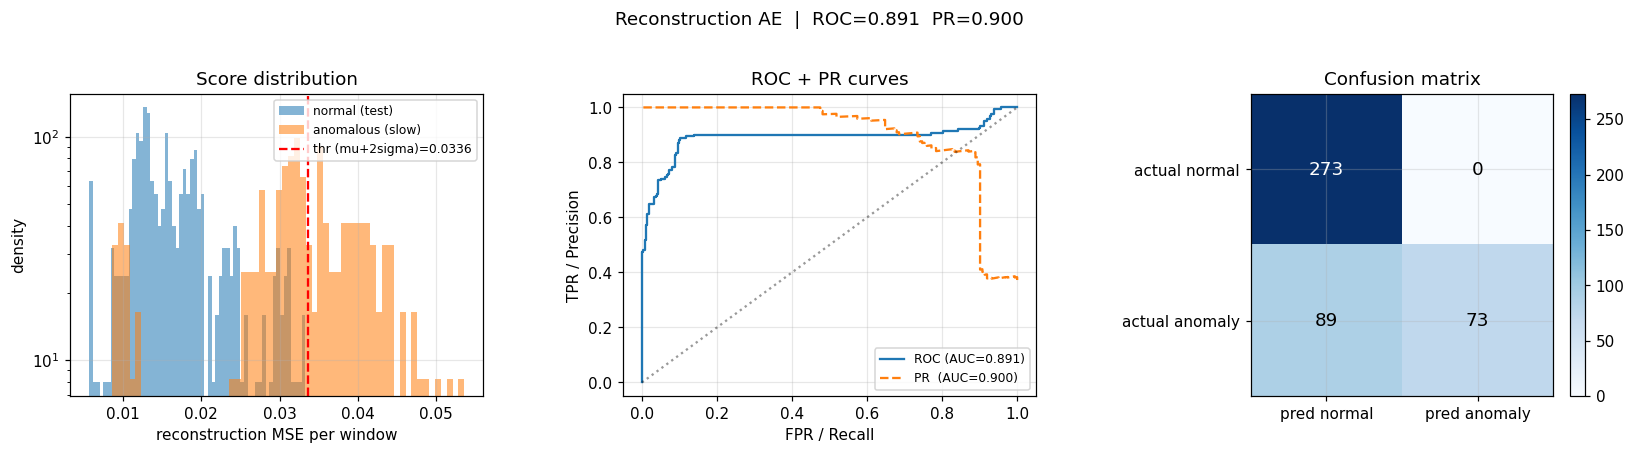

In [5]:
# Reconstruction score = mean MSE between W and model(W).
recon_sv = score_mean_mse(recon_model, W_val,  W_val)
recon_st = score_mean_mse(recon_model, W_test, W_test)
recon_ss_val = score_mean_mse(recon_model, W_slow_val, W_slow_val)
recon_ss = score_mean_mse(recon_model, W_slow, W_slow)  # W_slow is the untouched slow-test set

print(f"val_normal   n={recon_sv.size:4d}  mean={recon_sv.mean():.5f}  p99={np.percentile(recon_sv, 99):.5f}")
print(f"test_normal  n={recon_st.size:4d}  mean={recon_st.mean():.5f}  p99={np.percentile(recon_st, 99):.5f}")
print(f"slow_val     n={recon_ss_val.size:4d}  mean={recon_ss_val.mean():.5f}  p99={np.percentile(recon_ss_val, 99):.5f}")
print(f"slow_test    n={recon_ss.size:4d}  mean={recon_ss.mean():.5f}  p99={np.percentile(recon_ss, 99):.5f}")
print()

recon_res = evaluate_scores(recon_sv, recon_st, recon_ss, tag="Reconstruction AE")
attach_percentile_selection(recon_res, recon_ss_val)
print_headline(recon_res)
plot_diagnostics(recon_res, score_label="reconstruction MSE per window")


## 5. Forecasting AE - predict next from past

Input = first 64 timesteps of the window, target = next 64. Same network, same loss, same training budget. The model learns to predict near-future dynamics from recent past. Anomalies show up as windows where the future is *hard to predict* from the past.

[forecast AE] ConvAE1D  params=48,277  enc=(64, 32)
  [forecast AE] epoch 001 | train 0.176333 | val 0.121797 *
  [forecast AE] epoch 002 | train 0.109270 | val 0.110809 *
  [forecast AE] epoch 003 | train 0.088061 | val 0.101675 *
  [forecast AE] epoch 004 | train 0.071210 | val 0.088660 *
  [forecast AE] epoch 005 | train 0.056449 | val 0.077498 *
  [forecast AE] epoch 006 | train 0.044994 | val 0.068792 *
  [forecast AE] epoch 007 | train 0.039561 | val 0.060639 *
  [forecast AE] epoch 008 | train 0.037091 | val 0.060281 *
  [forecast AE] epoch 009 | train 0.036030 | val 0.057311 *
  [forecast AE] epoch 010 | train 0.034586 | val 0.055724 *
  [forecast AE] epoch 011 | train 0.033640 | val 0.055809
  [forecast AE] epoch 012 | train 0.032787 | val 0.053317 *
  [forecast AE] epoch 013 | train 0.032087 | val 0.052597 *
  [forecast AE] epoch 014 | train 0.031193 | val 0.050430 *
  [forecast AE] epoch 015 | train 0.030383 | val 0.048766 *
  [forecast AE] epoch 016 | train 0.029968 | val 0

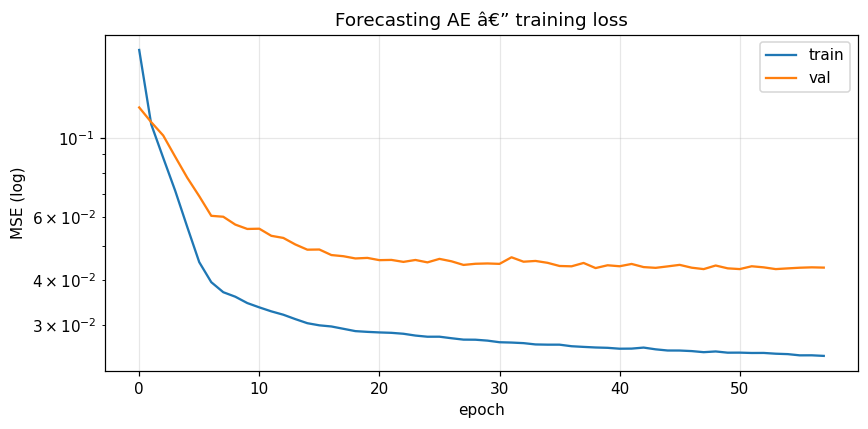

In [6]:
fc_model, fc_tr_losses, fc_va_losses, fc_best_val = train_model(
    forecast_train_loader, forecast_val_loader, tag="forecast AE")

torch.save({"model_state": fc_model.state_dict(),
            "train_losses": fc_tr_losses, "val_losses": fc_va_losses,
            "config": {"window_len": WINDOW_LEN, "objective": "forecast",
                       "forecast_half": FORECAST_HALF,
                       "enc_channels": list(ENC_CHANNELS),
                       "batch_size": BATCH_SIZE, "lr": LEARNING_RATE,
                       "epochs_run": len(fc_tr_losses),
                       "best_val": fc_best_val}},
           OUTPUT_DIR / "forecast_ae.pt")
print("saved ->", OUTPUT_DIR / "forecast_ae.pt")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(fc_tr_losses, label="train"); ax.plot(fc_va_losses, label="val")
ax.set_yscale("log"); ax.set_xlabel("epoch"); ax.set_ylabel("MSE (log)")
ax.set_title("Forecasting AE - training loss"); ax.legend()
plt.tight_layout(); plt.show()

val_normal   n= 273  mean=0.04303  p99=0.09401
test_normal  n= 273  mean=0.04253  p99=0.07453
slow_val     n= 162  mean=0.03603  p99=0.06045
slow_test    n= 162  mean=0.08303  p99=0.11195

[Forecasting AE]  ROC-AUC = 0.9639   PR-AUC = 0.9595
[Forecasting AE]  Threshold (val_normal mu+2sigma) = 0.068708

               pred normal | pred anomaly
actual normal        262           11
actual anomaly        16          146

              precision    recall  f1-score   support

      normal      0.942     0.960     0.951       273
     anomaly      0.930     0.901     0.915       162

    accuracy                          0.938       435
   macro avg      0.936     0.930     0.933       435
weighted avg      0.938     0.938     0.938       435



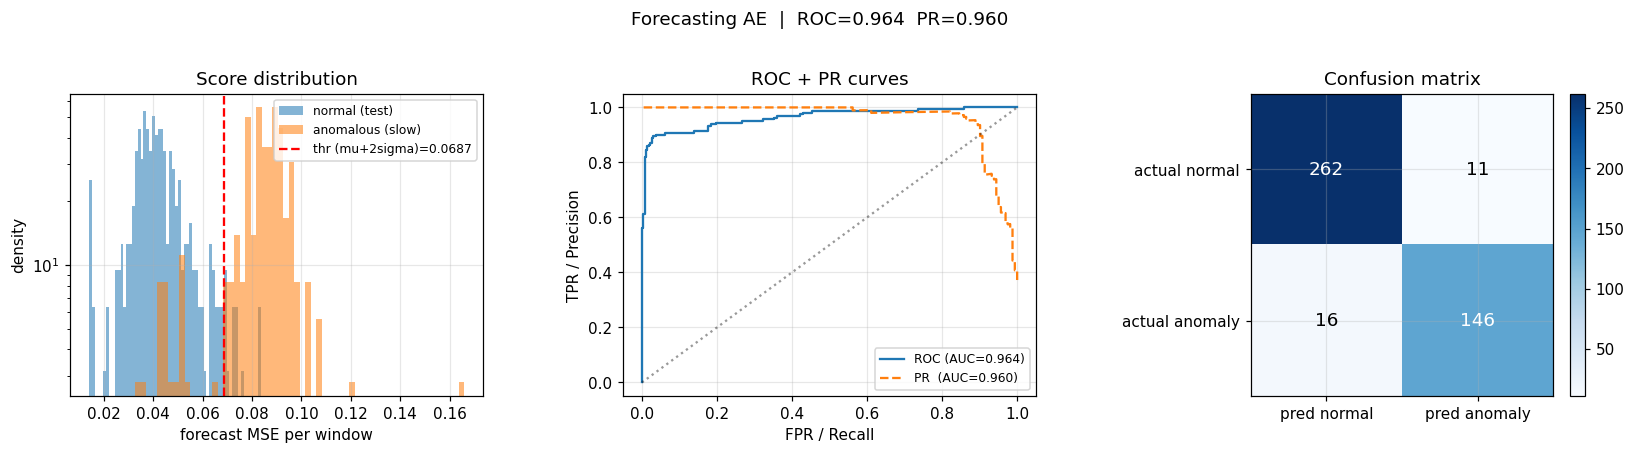

In [7]:
# Forecasting score = mean MSE between model(first 64) and next 64.
fc_sv = score_mean_mse(fc_model, X_val_in,  X_val_tg)
fc_st = score_mean_mse(fc_model, X_test_in, X_test_tg)
fc_ss_val = score_mean_mse(fc_model, X_slow_val_in, X_slow_val_tg)
fc_ss = score_mean_mse(fc_model, X_slow_in, X_slow_tg)  # slow-test only

print(f"val_normal   n={fc_sv.size:4d}  mean={fc_sv.mean():.5f}  p99={np.percentile(fc_sv, 99):.5f}")
print(f"test_normal  n={fc_st.size:4d}  mean={fc_st.mean():.5f}  p99={np.percentile(fc_st, 99):.5f}")
print(f"slow_val     n={fc_ss_val.size:4d}  mean={fc_ss_val.mean():.5f}  p99={np.percentile(fc_ss_val, 99):.5f}")
print(f"slow_test    n={fc_ss.size:4d}  mean={fc_ss.mean():.5f}  p99={np.percentile(fc_ss, 99):.5f}")
print()

fc_res = evaluate_scores(fc_sv, fc_st, fc_ss, tag="Forecasting AE")
attach_percentile_selection(fc_res, fc_ss_val)
print_headline(fc_res)
plot_diagnostics(fc_res, score_label="forecast MSE per window")


## 6. Final comparison

Side-by-side comparison of both objectives. Threshold-free metrics (ROC-AUC, PR-AUC) are the primary numbers - they don't depend on a threshold and are not subject to label leakage. F1 / P / R at `mu + 2sigma` of `val_normal` are reported as a label-free operating point.

                 model |  ROC-AUC |  PR-AUC |  F1 mu2  F1 pct |   pct |  TP  FP  TN  FN
----------------------------------------------------------------------------------------------------------
     Reconstruction AE |   0.8906 |  0.9003 |   0.621   0.615 |   p99 |  72   0 273  90
        Forecasting AE |   0.9639 |  0.9595 |   0.915   0.805 |   p80 | 153  65 208   9


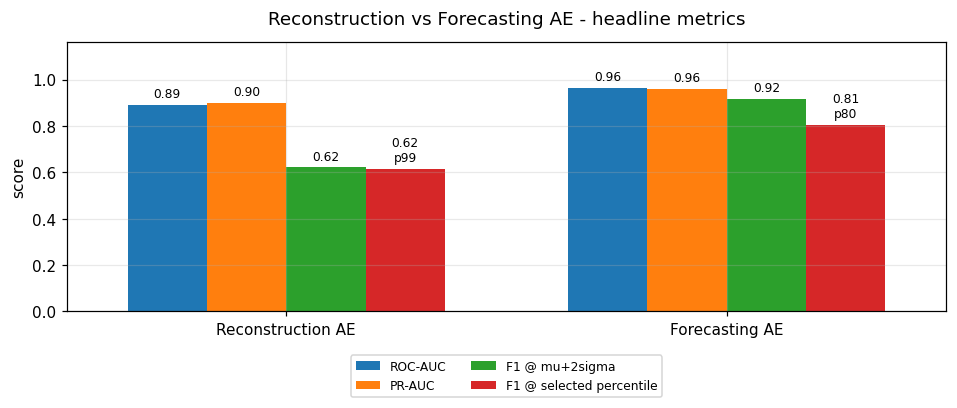


saved -> c:\Users\siava\Desktop\4th_Semester\ML-App\project-AM01\github_version\ML_APP_Anomaly_Detection\outputs\ae_compare\semi_supervised\compare_final.json

ROC-AUC winner: Forecasting AE  (0.964)
PR-AUC  winner: Forecasting AE


In [8]:
results = [recon_res, fc_res]

# ---------------- side-by-side text table ------------------------------
print(f"{'model':>22s} | {'ROC-AUC':>8s} | {'PR-AUC':>7s} | "
      f"{'F1 mu2':>7s} {'F1 pct':>7s} | {'pct':>5s} | {'TP':>3s} {'FP':>3s} {'TN':>3s} {'FN':>3s}")
print("-" * 106)
for r in results:
    op = r["operating_points"]["mu+2sigma"]
    pct = r["best_percentile"]
    print(f"{r['tag']:>22s} | {r['roc_auc']:8.4f} | {r['pr_auc']:7.4f} | "
          f"{op['F1']:7.3f} {pct['test_F1']:7.3f} | {pct['rule']:>5s} | "
          f"{pct['test_tp']:3d} {pct['test_fp']:3d} {pct['test_tn']:3d} {pct['test_fn']:3d}")

# ---------------- bar chart of ROC-AUC and PR-AUC ----------------------
labels = [r["tag"] for r in results]
roc = [r["roc_auc"] for r in results]
pr  = [r["pr_auc"]  for r in results]
f1_mu2 = [r["operating_points"]["mu+2sigma"]["F1"] for r in results]
f1_pct = [r["best_percentile"]["test_F1"] for r in results]
pct_rules = [r["best_percentile"]["rule"] for r in results]

plot_metric_bars(
    labels, roc, pr, f1_mu2, f1_pct, pct_rules,
    title="Reconstruction vs Forecasting AE - headline metrics",
    figsize=(8.8, 4.5),
)

# ---------------- save comparison JSON ---------------------------------
summary = {
    "config": {
        "window_len": WINDOW_LEN, "forecast_half": FORECAST_HALF,
        "enc_channels": list(ENC_CHANNELS), "batch_size": BATCH_SIZE,
        "epochs_cap": EPOCHS, "patience": PATIENCE, "lr": LEARNING_RATE,
        "data": "KukaNormal (action dropped, 85 features)",
        "slow_split": "first SLOW_VAL_FRAC slow windows for threshold validation; remaining slow windows for final test",
        "slow_val_frac": SLOW_VAL_FRAC,
        "n_slow_val": int(len(W_slow_val)),
        "n_test_normal": int(recon_st.size), "n_test_anomaly": int(recon_ss.size),
    },
    "models": {
        r["tag"]: {
            "roc_auc": r["roc_auc"],
            "pr_auc":  r["pr_auc"],
            "operating_points": r["operating_points"],
            "best_percentile": r["best_percentile"],
        } for r in results
    },
}
with open(OUTPUT_DIR / "compare_final.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, default=float)
print("\nsaved ->", OUTPUT_DIR / "compare_final.json")

# ---------------- one-line takeaway ------------------------------------
winner = max(results, key=lambda r: r["roc_auc"])
print(f"\nROC-AUC winner: {winner['tag']}  ({winner['roc_auc']:.3f})")
print(f"PR-AUC  winner: {max(results, key=lambda r: r['pr_auc'])['tag']}")

## 7. AAE - Adversarial Autoencoder (Pix2Pix-style)

We add a **discriminator** that judges whether a window is "real normal data" or "an AE reconstruction". The generator (= our `ConvAE1D`, unchanged) is now trained with **two** loss terms:

- **MSE** - same as before, drives reconstruction quality.
- **Adversarial** - fools the discriminator into thinking reconstructions are real.

This is the picture from the lecture slide (Adversarial Autoencoder = Pix2Pix-style: discriminator on the **output**, not on the latent). The recipe matches `Am_lab03.ipynb`:

- **Linear scalar D output** (no sigmoid) + **hinge loss**
- **Spectral norm** on every conv / linear in D
- **No BatchNorm on D's first layer**
- One D step, then one G step per minibatch
- Adam with `lr_G = 1e-3` (same as AE for fairness on MSE) and `lr_D = 1e-4` (slower so D doesn't crush G)
- `lambda_adv = 0.01` (MSE-dominated, like Pix2Pix's L1:GAN ratio)

Anomaly score is still `mean_MSE` per window - exactly the same scoring rule as the recon AE, so the AE-vs-AAE comparison is strictly apples-to-apples.

In [9]:
import torch.nn.functional as F
from torch.nn.utils.parametrizations import spectral_norm


class Discriminator1D(nn.Module):
    """Real-vs-fake classifier on windows of shape (B, F, L). Outputs a linear scalar per window."""
    def __init__(self, n_features, hidden_channels=(32, 64, 128), input_len=128, neg_slope=0.2):
        super().__init__()
        layers = []
        in_c = n_features
        for i, c in enumerate(hidden_channels):
            layers.append(spectral_norm(nn.Conv1d(in_c, c, kernel_size=4, stride=2, padding=1)))
            if i > 0:                                  # no BN on layer 0 (lab hint)
                layers.append(nn.BatchNorm1d(c))
            layers.append(nn.LeakyReLU(neg_slope, inplace=True))
            in_c = c
        self.conv = nn.Sequential(*layers)
        flat_len = (input_len // (2 ** len(hidden_channels))) * hidden_channels[-1]
        self.fc = spectral_norm(nn.Linear(flat_len, 1))

    def forward(self, x):
        z = self.conv(x).flatten(1)
        return self.fc(z).squeeze(-1)                  # (B,) linear score


def hinge_loss_D(d_real, d_fake):
    return F.relu(1.0 - d_real).mean() + F.relu(1.0 + d_fake).mean()

def hinge_loss_G(d_fake):
    return -d_fake.mean()


# --- AAE hyperparameters (everything else identical to the AE) ---------
LR_G_AAE     = 1e-3                # match the AE's LR -> fair on MSE training
LR_D_AAE     = 1e-4                # slower than G to avoid D domination
LAMBDA_ADV   = 0.01                # Pix2Pix-style: MSE dominates
BETAS_AAE    = (0.5, 0.999)        # GAN convention (Adam)

_D_probe = Discriminator1D(n_features=n_features, input_len=WINDOW_LEN).to(DEVICE)
print(f"Discriminator1D  params: {sum(p.numel() for p in _D_probe.parameters()):,}")
del _D_probe

Discriminator1D  params: 54,497


### 7.1 Train

Each minibatch:

1. **D step**: hinge loss on `D(x_real)` vs `D(G(x).detach())`.
2. **G step**: `MSE(G(x), x) + lambda_adv * (-D(G(x)).mean())`.

Early-stop on **val MSE** (not val GAN losses - we care about reconstruction). The training-diagnostics plot also shows `D(real)` vs `D(fake)` so we can spot mode collapse / D running away.

[AAE]  G params=48,277   D params=54,497   lambda_adv=0.01
  [AAE] ep 001 | MSE tr=0.17161 val=0.12013 | L_D=2.703  L_G_adv=-0.555 | D(real)=+0.22 D(fake)=+0.90 *
  [AAE] ep 002 | MSE tr=0.09836 val=0.10728 | L_D=1.946  L_G_adv=+0.147 | D(real)=+0.11 D(fake)=+0.04 *
  [AAE] ep 003 | MSE tr=0.07885 val=0.09607 | L_D=1.872  L_G_adv=+0.245 | D(real)=-0.01 D(fake)=-0.15 *
  [AAE] ep 004 | MSE tr=0.06165 val=0.07954 | L_D=2.075  L_G_adv=+0.225 | D(real)=-0.23 D(fake)=-0.16 *
  [AAE] ep 005 | MSE tr=0.05221 val=0.07015 | L_D=2.014  L_G_adv=+0.293 | D(real)=-0.25 D(fake)=-0.24 *
  [AAE] ep 006 | MSE tr=0.04419 val=0.06066 | L_D=1.926  L_G_adv=+0.249 | D(real)=-0.12 D(fake)=-0.20 *
  [AAE] ep 007 | MSE tr=0.03724 val=0.06594 | L_D=1.946  L_G_adv=+0.280 | D(real)=-0.17 D(fake)=-0.23
  [AAE] ep 008 | MSE tr=0.03189 val=0.06085 | L_D=2.034  L_G_adv=+0.156 | D(real)=-0.15 D(fake)=-0.12
  [AAE] ep 009 | MSE tr=0.02938 val=0.04696 | L_D=2.126  L_G_adv=+0.105 | D(real)=-0.20 D(fake)=-0.07 *
  [AAE] e

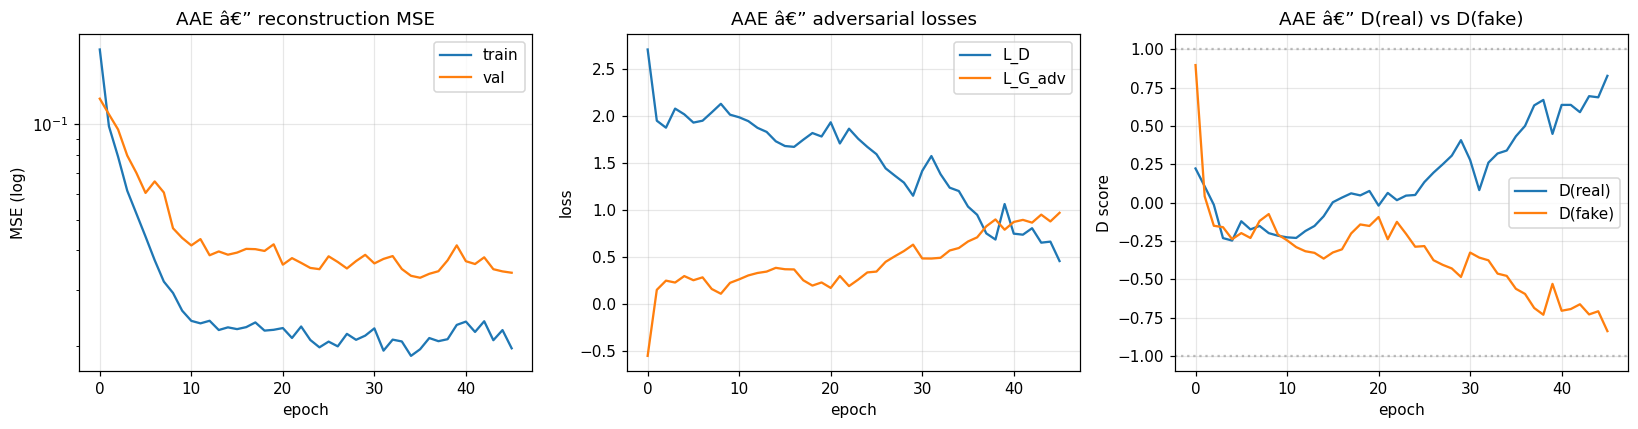

In [10]:
def train_aae(train_loader, val_loader, *, tag="AAE", seed=42):
    """Train G = ConvAE1D and D = Discriminator1D adversarially. Early-stop on val MSE.
    Returns (G, D, history, best_val_mse)."""
    torch.manual_seed(seed); np.random.seed(seed)
    G = ConvAE1D(n_features=n_features, enc_channels=ENC_CHANNELS).to(DEVICE)
    D = Discriminator1D(n_features=n_features, input_len=WINDOW_LEN).to(DEVICE)

    opt_G = torch.optim.Adam(G.parameters(), lr=LR_G_AAE, betas=BETAS_AAE)
    opt_D = torch.optim.Adam(D.parameters(), lr=LR_D_AAE, betas=BETAS_AAE)
    mse   = nn.MSELoss()

    nG = sum(p.numel() for p in G.parameters())
    nD = sum(p.numel() for p in D.parameters())
    print(f"[{tag}]  G params={nG:,}   D params={nD:,}   lambda_adv={LAMBDA_ADV}")

    hist = {"train_mse": [], "val_mse": [],
            "loss_D": [], "loss_G_adv": [],
            "d_real": [], "d_fake": []}
    best_val, best_state, remaining = float("inf"), None, PATIENCE

    for epoch in range(1, EPOCHS + 1):
        G.train(); D.train()
        sums = {k: 0.0 for k in ("mse", "lD", "lGadv", "dreal", "dfake")}
        n_seen = 0
        for (x_real, _) in train_loader:                        # TensorDataset(W,W)
            x_real = x_real.to(DEVICE, non_blocking=True)

            # ---- D step --------------------------------------------------
            opt_D.zero_grad(set_to_none=True)
            with torch.no_grad():
                x_fake_d = G(x_real)
            d_real = D(x_real)
            d_fake = D(x_fake_d)
            loss_D = hinge_loss_D(d_real, d_fake)
            loss_D.backward()
            opt_D.step()

            # ---- G step --------------------------------------------------
            opt_G.zero_grad(set_to_none=True)
            x_fake = G(x_real)
            mse_loss   = mse(x_fake, x_real)
            adv_loss_G = hinge_loss_G(D(x_fake))
            loss_G     = mse_loss + LAMBDA_ADV * adv_loss_G
            loss_G.backward()
            nn.utils.clip_grad_norm_(G.parameters(), GRAD_CLIP)
            opt_G.step()

            bs = x_real.size(0); n_seen += bs
            sums["mse"]   += mse_loss.item()   * bs
            sums["lD"]    += loss_D.item()     * bs
            sums["lGadv"] += adv_loss_G.item() * bs
            sums["dreal"] += d_real.mean().item() * bs
            sums["dfake"] += d_fake.mean().item() * bs

        tr_mse   = sums["mse"]   / n_seen
        tr_lD    = sums["lD"]    / n_seen
        tr_lGadv = sums["lGadv"] / n_seen
        tr_dr    = sums["dreal"] / n_seen
        tr_df    = sums["dfake"] / n_seen

        # ---- val (MSE only) ---------------------------------------------
        G.eval()
        with torch.no_grad():
            tot, n = 0.0, 0
            for (xv, _) in val_loader:
                xv = xv.to(DEVICE, non_blocking=True)
                tot += mse(G(xv), xv).item() * xv.size(0); n += xv.size(0)
            va_mse = tot / max(n, 1)

        hist["train_mse"].append(tr_mse);   hist["val_mse"].append(va_mse)
        hist["loss_D"].append(tr_lD);       hist["loss_G_adv"].append(tr_lGadv)
        hist["d_real"].append(tr_dr);       hist["d_fake"].append(tr_df)

        improved = va_mse < best_val - 1e-6
        if improved:
            best_val = va_mse
            best_state = copy.deepcopy(G.state_dict())
            remaining = PATIENCE
        print(f"  [{tag}] ep {epoch:03d} | MSE tr={tr_mse:.5f} val={va_mse:.5f} | "
              f"L_D={tr_lD:.3f}  L_G_adv={tr_lGadv:+.3f} | "
              f"D(real)={tr_dr:+.2f} D(fake)={tr_df:+.2f}{' *' if improved else ''}")
        if not improved:
            remaining -= 1
            if remaining <= 0:
                print(f"  [{tag}] Early stop at epoch {epoch} (best val MSE {best_val:.6f})")
                break

    G.load_state_dict(best_state)
    return G, D, hist, best_val


aae_G, aae_D, aae_hist, aae_best_val = train_aae(
    recon_train_loader, recon_val_loader, tag="AAE")

torch.save({"G_state": aae_G.state_dict(), "D_state": aae_D.state_dict(),
            "history": aae_hist,
            "config": {"window_len": WINDOW_LEN, "objective": "adversarial reconstruction",
                       "enc_channels": list(ENC_CHANNELS),
                       "batch_size": BATCH_SIZE,
                       "lr_G": LR_G_AAE, "lr_D": LR_D_AAE,
                       "lambda_adv": LAMBDA_ADV, "betas": list(BETAS_AAE),
                       "epochs_run": len(aae_hist["train_mse"]),
                       "best_val_mse": aae_best_val}},
           OUTPUT_DIR / "aae.pt")
print("saved ->", OUTPUT_DIR / "aae.pt")

# --- training diagnostics: MSE curves + L_D/L_G_adv + D(real)/D(fake) ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.plot(aae_hist["train_mse"], label="train"); ax.plot(aae_hist["val_mse"], label="val")
ax.set_yscale("log"); ax.set_xlabel("epoch"); ax.set_ylabel("MSE (log)")
ax.set_title("AAE - reconstruction MSE"); ax.legend()

ax = axes[1]
ax.plot(aae_hist["loss_D"],     label="L_D")
ax.plot(aae_hist["loss_G_adv"], label="L_G_adv")
ax.set_xlabel("epoch"); ax.set_ylabel("loss")
ax.set_title("AAE - adversarial losses"); ax.legend()

ax = axes[2]
ax.plot(aae_hist["d_real"], label="D(real)")
ax.plot(aae_hist["d_fake"], label="D(fake)")
ax.axhline(+1, color="grey", linestyle=":", alpha=0.5)
ax.axhline(-1, color="grey", linestyle=":", alpha=0.5)
ax.set_xlabel("epoch"); ax.set_ylabel("D score")
ax.set_title("AAE - D(real) vs D(fake)"); ax.legend()

plt.tight_layout(); plt.show()

### 7.2 Evaluate

Same scoring rule as the recon AE (`mean_MSE` per window), same evaluation helpers, same threshold rule (`mu + 2sigma` of val_normal). The AAE-vs-AE comparison is now strictly head-to-head: only the training objective differs (MSE vs MSE+adv).

val_normal   n= 273  mean=0.03280  p99=0.04268
test_normal  n= 273  mean=0.02629  p99=0.04069
slow_val     n= 162  mean=0.01686  p99=0.02525
slow_test    n= 162  mean=0.04893  p99=0.06021

[AAE]  ROC-AUC = 0.9409   PR-AUC = 0.9475
[AAE]  Threshold (val_normal mu+2sigma) = 0.041905

               pred normal | pred anomaly
actual normal        272            1
actual anomaly        23          139

              precision    recall  f1-score   support

      normal      0.922     0.996     0.958       273
     anomaly      0.993     0.858     0.921       162

    accuracy                          0.945       435
   macro avg      0.957     0.927     0.939       435
weighted avg      0.948     0.945     0.944       435



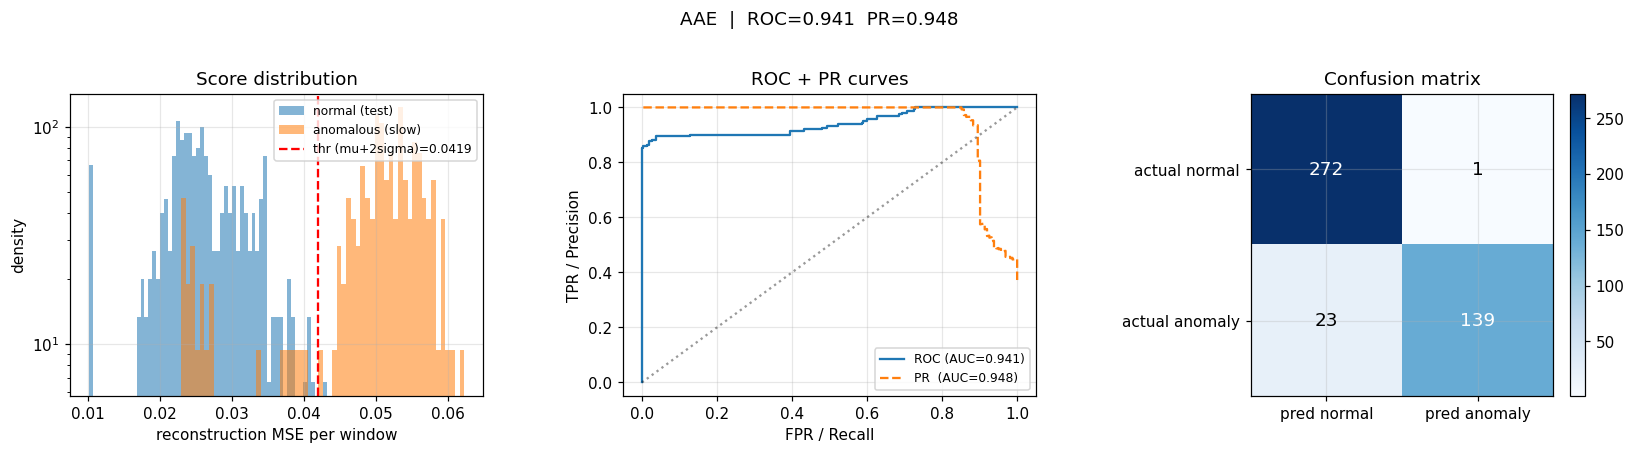

In [11]:
# Reconstruction score = mean MSE between W and G(W). Same scoring as the recon AE.
aae_sv = score_mean_mse(aae_G, W_val,  W_val)
aae_st = score_mean_mse(aae_G, W_test, W_test)
aae_ss_val = score_mean_mse(aae_G, W_slow_val, W_slow_val)
aae_ss = score_mean_mse(aae_G, W_slow, W_slow)  # W_slow is the untouched slow-test set

print(f"val_normal   n={aae_sv.size:4d}  mean={aae_sv.mean():.5f}  p99={np.percentile(aae_sv, 99):.5f}")
print(f"test_normal  n={aae_st.size:4d}  mean={aae_st.mean():.5f}  p99={np.percentile(aae_st, 99):.5f}")
print(f"slow_val     n={aae_ss_val.size:4d}  mean={aae_ss_val.mean():.5f}  p99={np.percentile(aae_ss_val, 99):.5f}")
print(f"slow_test    n={aae_ss.size:4d}  mean={aae_ss.mean():.5f}  p99={np.percentile(aae_ss, 99):.5f}")
print()

aae_res = evaluate_scores(aae_sv, aae_st, aae_ss, tag="AAE")
attach_percentile_selection(aae_res, aae_ss_val)
print_headline(aae_res)
plot_diagnostics(aae_res, score_label="reconstruction MSE per window")


## 8. Three-way comparison - AE vs Forecasting AE vs AAE

The full story in one table. Two independent ablations:

- **Recon AE -> Forecasting AE**: changes the *objective* (reconstruct vs predict-next).
- **Recon AE -> AAE**: changes the *training regularization* (MSE only vs MSE + adversarial).

Threshold-free metrics (ROC-AUC, PR-AUC) are the primary numbers.

                 model |  ROC-AUC |  PR-AUC |  F1 mu2  F1 pct |   pct |  TP  FP  TN  FN
----------------------------------------------------------------------------------------------------------
     Reconstruction AE |   0.8906 |  0.9003 |   0.621   0.615 |   p99 |  72   0 273  90
        Forecasting AE |   0.9639 |  0.9595 |   0.915   0.805 |   p80 | 153  65 208   9
                   AAE |   0.9409 |  0.9475 |   0.921   0.917 |   p99 | 138   1 272  24


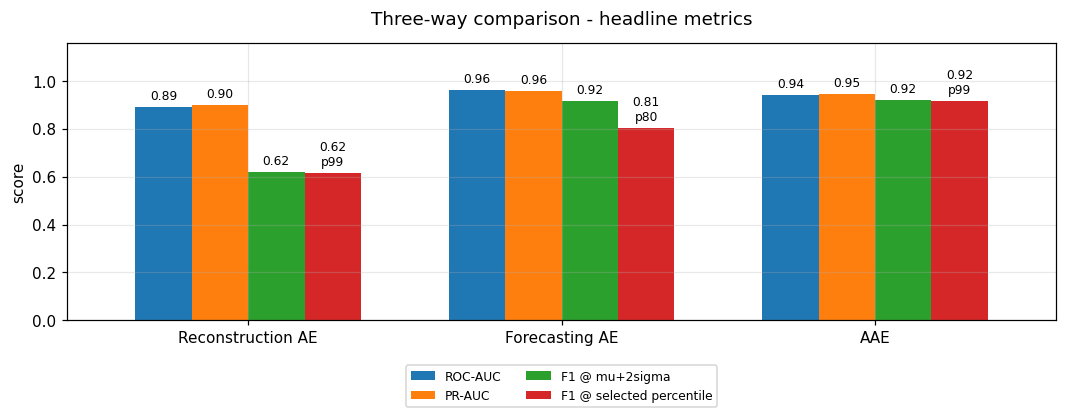


saved -> c:\Users\siava\Desktop\4th_Semester\ML-App\project-AM01\github_version\ML_APP_Anomaly_Detection\outputs\ae_compare\semi_supervised\compare_3way.json

ROC-AUC winner: Forecasting AE  (0.964)
PR-AUC  winner: Forecasting AE  (0.960)

AAE vs Reconstruction AE (head-to-head):
  Delta ROC-AUC = +0.0503   Delta PR-AUC = +0.0472
  --> Adversarial regularization HELPS ROC-AUC.
  --> Adversarial regularization HELPS PR-AUC.


In [12]:
results_3way = [recon_res, fc_res, aae_res]

# ---------------- side-by-side text table ------------------------------
print(f"{'model':>22s} | {'ROC-AUC':>8s} | {'PR-AUC':>7s} | "
      f"{'F1 mu2':>7s} {'F1 pct':>7s} | {'pct':>5s} | {'TP':>3s} {'FP':>3s} {'TN':>3s} {'FN':>3s}")
print("-" * 106)
for r in results_3way:
    op = r["operating_points"]["mu+2sigma"]
    pct = r["best_percentile"]
    print(f"{r['tag']:>22s} | {r['roc_auc']:8.4f} | {r['pr_auc']:7.4f} | "
          f"{op['F1']:7.3f} {pct['test_F1']:7.3f} | {pct['rule']:>5s} | "
          f"{pct['test_tp']:3d} {pct['test_fp']:3d} {pct['test_tn']:3d} {pct['test_fn']:3d}")

# ---------------- bar chart: ROC-AUC, PR-AUC, F1 -----------------------
labels = [r["tag"] for r in results_3way]
roc = [r["roc_auc"] for r in results_3way]
pr  = [r["pr_auc"]  for r in results_3way]
f1_mu2 = [r["operating_points"]["mu+2sigma"]["F1"] for r in results_3way]
f1_pct = [r["best_percentile"]["test_F1"] for r in results_3way]
pct_rules = [r["best_percentile"]["rule"] for r in results_3way]

plot_metric_bars(
    labels, roc, pr, f1_mu2, f1_pct, pct_rules,
    title="Three-way comparison - headline metrics",
    figsize=(9.8, 4.6),
)

# ---------------- save 3-way comparison JSON ---------------------------
summary_3way = {
    "config": {
        "window_len": WINDOW_LEN, "forecast_half": FORECAST_HALF,
        "enc_channels": list(ENC_CHANNELS), "batch_size": BATCH_SIZE,
        "epochs_cap": EPOCHS, "patience": PATIENCE,
        "ae_lr": LEARNING_RATE,
        "aae_lr_G": LR_G_AAE, "aae_lr_D": LR_D_AAE,
        "aae_lambda_adv": LAMBDA_ADV, "aae_betas": list(BETAS_AAE),
        "data": "KukaNormal (action dropped, 85 features)",
        "slow_split": "first SLOW_VAL_FRAC slow windows for threshold validation; remaining slow windows for final test",
        "slow_val_frac": SLOW_VAL_FRAC,
        "n_slow_val": int(len(W_slow_val)),
        "n_test_normal": int(recon_st.size), "n_test_anomaly": int(recon_ss.size),
    },
    "models": {
        r["tag"]: {
            "roc_auc": r["roc_auc"],
            "pr_auc":  r["pr_auc"],
            "operating_points": r["operating_points"],
            "best_percentile": r["best_percentile"],
        } for r in results_3way
    },
}
with open(OUTPUT_DIR / "compare_3way.json", "w", encoding="utf-8") as f:
    json.dump(summary_3way, f, indent=2, default=float)
print("\nsaved ->", OUTPUT_DIR / "compare_3way.json")

# ---------------- one-line takeaways -----------------------------------
roc_win = max(results_3way, key=lambda r: r["roc_auc"])
pr_win  = max(results_3way, key=lambda r: r["pr_auc"])
print(f"\nROC-AUC winner: {roc_win['tag']}  ({roc_win['roc_auc']:.3f})")
print(f"PR-AUC  winner: {pr_win['tag']}  ({pr_win['pr_auc']:.3f})")

# Head-to-head: recon AE vs AAE (the actual AAE question we set out to answer)
delta_roc = aae_res["roc_auc"] - recon_res["roc_auc"]
delta_pr  = aae_res["pr_auc"]  - recon_res["pr_auc"]
print(f"\nAAE vs Reconstruction AE (head-to-head):")
print(f"  Delta ROC-AUC = {delta_roc:+.4f}   Delta PR-AUC = {delta_pr:+.4f}")
print(f"  --> Adversarial regularization {'HELPS' if delta_roc > 0 else 'does NOT help'} ROC-AUC.")
print(f"  --> Adversarial regularization {'HELPS' if delta_pr  > 0 else 'does NOT help'} PR-AUC.")

## 9. AAE v2 sweep - adversarial hyperparameters

This section keeps the comparison honest:

- same `ConvAE1D` generator as the reconstruction AE and AAE v1
- same `Discriminator1D` architecture as AAE v1
- same inference/anomaly score: reconstruction `mean_MSE` per window

Only the adversarial training recipe changes: `lambda_adv`, discriminator learning rate, and the generator adversarial loss variant.

The best v2 candidate is selected only on `val_normal + slow_val`; `test_normal + slow_test` is kept for final reporting.

In [13]:
# --- AAE v2 sweep config ------------------------------------------------
# All variants use the same generator/discriminator architecture and MSE inference score.
AAE_V2_SWEEP_CONFIGS = [
    {"name": "lam001_d1e4_linear", "lambda_adv": 0.001, "lr_G": 1e-3, "lr_D": 1e-4, "g_loss": "linear"},
    {"name": "lam003_d1e4_linear", "lambda_adv": 0.003, "lr_G": 1e-3, "lr_D": 1e-4, "g_loss": "linear"},
    {"name": "lam001_d2e4_linear", "lambda_adv": 0.001, "lr_G": 1e-3, "lr_D": 2e-4, "g_loss": "linear"},
    {"name": "lam003_d2e4_linear", "lambda_adv": 0.003, "lr_G": 1e-3, "lr_D": 2e-4, "g_loss": "linear"},
    {"name": "lam001_d4e4_linear", "lambda_adv": 0.001, "lr_G": 1e-3, "lr_D": 4e-4, "g_loss": "linear"},
    {"name": "lam003_d4e4_linear", "lambda_adv": 0.003, "lr_G": 1e-3, "lr_D": 4e-4, "g_loss": "linear"},
    {"name": "lam001_d2e4_hinge",  "lambda_adv": 0.001, "lr_G": 1e-3, "lr_D": 2e-4, "g_loss": "hinge"},
    {"name": "lam003_d2e4_hinge",  "lambda_adv": 0.003, "lr_G": 1e-3, "lr_D": 2e-4, "g_loss": "hinge"},
]

AAE_V2_SWEEP_EPOCHS = EPOCHS
AAE_V2_SWEEP_PATIENCE = PATIENCE
AAE_V2_BETAS = BETAS_AAE


def generator_adv_loss_v2(d_fake, mode):
    if mode == "linear":
        return -d_fake.mean()                  # same as AAE v1 / lab notebook
    if mode == "hinge":
        return F.relu(1.0 - d_fake).mean()     # slide-style generator hinge
    raise ValueError(f"unknown generator loss mode: {mode}")


def compact_result(res):
    out = {
        "tag": res["tag"],
        "roc_auc": res["roc_auc"],
        "pr_auc": res["pr_auc"],
        "threshold": res["threshold"],
        "operating_points": res["operating_points"],
    }
    if "selection" in res:
        out["selection"] = res["selection"]
    if "best_percentile" in res:
        out["best_percentile"] = res["best_percentile"]
    return out


def train_aae_v2_variant(cfg, *, seed=42):
    """Train one AAE v2 candidate. Returns G, D, history, best val MSE."""
    torch.manual_seed(seed); np.random.seed(seed)
    G = ConvAE1D(n_features=n_features, enc_channels=ENC_CHANNELS).to(DEVICE)
    D = Discriminator1D(n_features=n_features, input_len=WINDOW_LEN).to(DEVICE)

    opt_G = torch.optim.Adam(G.parameters(), lr=cfg["lr_G"], betas=AAE_V2_BETAS)
    opt_D = torch.optim.Adam(D.parameters(), lr=cfg["lr_D"], betas=AAE_V2_BETAS)
    mse = nn.MSELoss()

    hist = {"train_mse": [], "val_mse": [], "loss_D": [], "loss_G_adv": [],
            "d_real": [], "d_fake": []}
    best_val, best_state, remaining = float("inf"), None, AAE_V2_SWEEP_PATIENCE
    tag = cfg["name"]
    print(f"\n[AAE v2:{tag}] lambda={cfg['lambda_adv']} lr_G={cfg['lr_G']:g} "
          f"lr_D={cfg['lr_D']:g} g_loss={cfg['g_loss']}")

    for epoch in range(1, AAE_V2_SWEEP_EPOCHS + 1):
        G.train(); D.train()
        sums = {k: 0.0 for k in ("mse", "lD", "lGadv", "dreal", "dfake")}
        n_seen = 0

        for (x_real, _) in recon_train_loader:
            x_real = x_real.to(DEVICE, non_blocking=True)

            # D step: real normal windows vs detached reconstructions.
            opt_D.zero_grad(set_to_none=True)
            with torch.no_grad():
                x_fake_d = G(x_real)
            d_real = D(x_real)
            d_fake = D(x_fake_d)
            loss_D = hinge_loss_D(d_real, d_fake)
            loss_D.backward()
            opt_D.step()

            # G step: reconstruction MSE remains dominant.
            opt_G.zero_grad(set_to_none=True)
            x_fake = G(x_real)
            mse_loss = mse(x_fake, x_real)
            adv_loss_G = generator_adv_loss_v2(D(x_fake), cfg["g_loss"])
            loss_G = mse_loss + cfg["lambda_adv"] * adv_loss_G
            loss_G.backward()
            nn.utils.clip_grad_norm_(G.parameters(), GRAD_CLIP)
            opt_G.step()

            bs = x_real.size(0); n_seen += bs
            sums["mse"] += mse_loss.item() * bs
            sums["lD"] += loss_D.item() * bs
            sums["lGadv"] += adv_loss_G.item() * bs
            sums["dreal"] += d_real.mean().item() * bs
            sums["dfake"] += d_fake.mean().item() * bs

        tr_mse = sums["mse"] / n_seen
        tr_lD = sums["lD"] / n_seen
        tr_lGadv = sums["lGadv"] / n_seen
        tr_dr = sums["dreal"] / n_seen
        tr_df = sums["dfake"] / n_seen

        G.eval()
        with torch.no_grad():
            tot, n = 0.0, 0
            for (xv, _) in recon_val_loader:
                xv = xv.to(DEVICE, non_blocking=True)
                tot += mse(G(xv), xv).item() * xv.size(0); n += xv.size(0)
            va_mse = tot / max(n, 1)

        hist["train_mse"].append(tr_mse); hist["val_mse"].append(va_mse)
        hist["loss_D"].append(tr_lD); hist["loss_G_adv"].append(tr_lGadv)
        hist["d_real"].append(tr_dr); hist["d_fake"].append(tr_df)

        improved = va_mse < best_val - 1e-6
        if improved:
            best_val = va_mse
            best_state = {"G": copy.deepcopy(G.state_dict()), "D": copy.deepcopy(D.state_dict())}
            remaining = AAE_V2_SWEEP_PATIENCE
        else:
            remaining -= 1

        print(f"  ep {epoch:03d} | MSE tr={tr_mse:.5f} val={va_mse:.5f} | "
              f"L_D={tr_lD:.3f} L_G_adv={tr_lGadv:+.3f} | "
              f"D(real)={tr_dr:+.2f} D(fake)={tr_df:+.2f}{' *' if improved else ''}")
        if remaining <= 0:
            print(f"  early stop at epoch {epoch} (best val MSE {best_val:.6f})")
            break

    G.load_state_dict(best_state["G"])
    D.load_state_dict(best_state["D"])
    return G, D, hist, best_val


def evaluate_aae_v2_variant(G, cfg):
    sv = score_mean_mse(G, W_val, W_val)
    ss_val = score_mean_mse(G, W_slow_val, W_slow_val)
    st = score_mean_mse(G, W_test, W_test)
    ss = score_mean_mse(G, W_slow, W_slow)

    y_val = np.concatenate([np.zeros(sv.size, np.int64), np.ones(ss_val.size, np.int64)])
    s_val = np.concatenate([sv, ss_val])
    val_roc_auc = float(roc_auc_score(y_val, s_val))
    val_pr_auc = float(average_precision_score(y_val, s_val))

    res = evaluate_scores(sv, st, ss, tag=f"AAE v2 {cfg['name']}")
    attach_percentile_selection(res, ss_val, display_name=f"AAE v2 {cfg['name']}")
    pct = res["best_percentile"]
    res["selection"] = {
        "criterion": "validation PR-AUC, ROC-AUC tie-breaker on val_normal + slow_val",
        "val_roc_auc": val_roc_auc,
        "val_pr_auc": val_pr_auc,
    }
    print(f"  scores: val_normal_mean={sv.mean():.5f} slow_val_mean={ss_val.mean():.5f} | "
          f"val_PR={val_pr_auc:.4f} val_ROC={val_roc_auc:.4f} | "
          f"test_ROC={res['roc_auc']:.4f} test_PR={res['pr_auc']:.4f} "
          f"F1_mu2={res['operating_points']['mu+2sigma']['F1']:.4f} "
          f"{pct['rule']}={pct['test_F1']:.4f}")
    return res, {"sv": sv, "ss_val": ss_val, "st": st, "ss": ss}


print(f"AAE v2 sweep configs: {len(AAE_V2_SWEEP_CONFIGS)}")

AAE v2 sweep configs: 8


### 9.1 Run the sweep

This can take several minutes on GPU. Each candidate uses the same reconstruction-MSE scoring rule as the AE and AAE v1. The sweep winner is chosen by validation PR-AUC with validation ROC-AUC as the tie-breaker.

In [14]:
aae_v2_runs = []

for cfg in AAE_V2_SWEEP_CONFIGS:
    G, D, hist, best_val = train_aae_v2_variant(cfg, seed=42)
    res, scores = evaluate_aae_v2_variant(G, cfg)

    ckpt_path = OUTPUT_DIR / f"aae_v2_{cfg['name']}.pt"
    torch.save({
        "G_state": G.state_dict(),
        "D_state": D.state_dict(),
        "history": hist,
        "config": {**cfg, "epochs_run": len(hist["train_mse"]), "best_val_mse": best_val},
        "metrics": compact_result(res),
    }, ckpt_path)

    aae_v2_runs.append({
        "cfg": cfg,
        "G": G,
        "D": D,
        "history": hist,
        "best_val": best_val,
        "result": res,
        "scores": scores,
        "checkpoint": str(ckpt_path),
    })
    print("saved ->", ckpt_path)

# Choose the headline v2 on validation data only. Test metrics are for final reporting.
best_run = max(
    aae_v2_runs,
    key=lambda r: (r["result"]["selection"]["val_pr_auc"],
                   r["result"]["selection"]["val_roc_auc"]),
)
aae_v2_best_res = best_run["result"]
aae_v2_best_cfg = best_run["cfg"]
aae_v2_best_G = best_run["G"]
aae_v2_best_D = best_run["D"]

torch.save({
    "G_state": aae_v2_best_G.state_dict(),
    "D_state": aae_v2_best_D.state_dict(),
    "history": best_run["history"],
    "config": {**aae_v2_best_cfg, "best_val_mse": best_run["best_val"],
               "selection": aae_v2_best_res["selection"]},
    "metrics": compact_result(aae_v2_best_res),
}, OUTPUT_DIR / "aae_v2_best.pt")

print("\nBest AAE v2 by validation PR-AUC (ROC-AUC tie-breaker):")
print(aae_v2_best_cfg)
sel = aae_v2_best_res["selection"]
print(f"Validation: PR={sel['val_pr_auc']:.4f} ROC={sel['val_roc_auc']:.4f}")
print(f"Final test: ROC={aae_v2_best_res['roc_auc']:.4f} PR={aae_v2_best_res['pr_auc']:.4f} "
      f"F1={aae_v2_best_res['operating_points']['mu+2sigma']['F1']:.4f}")
print("saved ->", OUTPUT_DIR / "aae_v2_best.pt")


[AAE v2:lam001_d1e4_linear] lambda=0.001 lr_G=0.001 lr_D=0.0001 g_loss=linear
  ep 001 | MSE tr=0.15239 val=0.10434 | L_D=1.243 L_G_adv=+0.711 | D(real)=+0.36 D(fake)=-0.47 *
  ep 002 | MSE tr=0.07597 val=0.08060 | L_D=0.964 L_G_adv=+0.795 | D(real)=+0.44 D(fake)=-0.65 *
  ep 003 | MSE tr=0.05605 val=0.06792 | L_D=0.793 L_G_adv=+0.866 | D(real)=+0.51 D(fake)=-0.77 *
  ep 004 | MSE tr=0.04462 val=0.06278 | L_D=0.492 L_G_adv=+0.991 | D(real)=+0.79 D(fake)=-0.88 *
  ep 005 | MSE tr=0.03506 val=0.05488 | L_D=0.442 L_G_adv=+1.027 | D(real)=+0.83 D(fake)=-0.92 *
  ep 006 | MSE tr=0.02921 val=0.04645 | L_D=0.650 L_G_adv=+0.936 | D(real)=+0.65 D(fake)=-0.81 *
  ep 007 | MSE tr=0.02671 val=0.05339 | L_D=0.434 L_G_adv=+1.051 | D(real)=+0.87 D(fake)=-0.96
  ep 008 | MSE tr=0.02661 val=0.04335 | L_D=0.156 L_G_adv=+1.280 | D(real)=+1.18 D(fake)=-1.20 *
  ep 009 | MSE tr=0.02491 val=0.04212 | L_D=0.093 L_G_adv=+1.374 | D(real)=+1.32 D(fake)=-1.28 *
  ep 010 | MSE tr=0.02452 val=0.04035 | L_D=0.113 

### 9.2 Sweep results and final AE-vs-AAE comparison

                 variant |  lambda |    lr_D |  G loss | val PR val ROC | test ROC test PR test F1 |     P     R
-------------------------------------------------------------------------------------------------------------------------
       lam003_d2e4_hinge |   0.003 | 2.0e-04 |   hinge |  0.217   0.017 |    0.892   0.834   0.711 | 0.874 0.599
      lam003_d1e4_linear |   0.003 | 1.0e-04 |  linear |  0.217   0.020 |    0.929   0.917   0.696 | 0.967 0.543
      lam001_d4e4_linear |   0.001 | 4.0e-04 |  linear |  0.216   0.013 |    0.920   0.939   0.749 | 1.000 0.599
      lam003_d2e4_linear |   0.003 | 2.0e-04 |  linear |  0.216   0.008 |    0.908   0.926   0.877 | 0.897 0.858
      lam003_d4e4_linear |   0.003 | 4.0e-04 |  linear |  0.216   0.004 |    0.916   0.931   0.621 | 1.000 0.451
      lam001_d1e4_linear |   0.001 | 1.0e-04 |  linear |  0.216   0.003 |    0.889   0.901   0.380 | 1.000 0.235
      lam001_d2e4_linear |   0.001 | 2.0e-04 |  linear |  0.216   0.001 |    0.827   0.

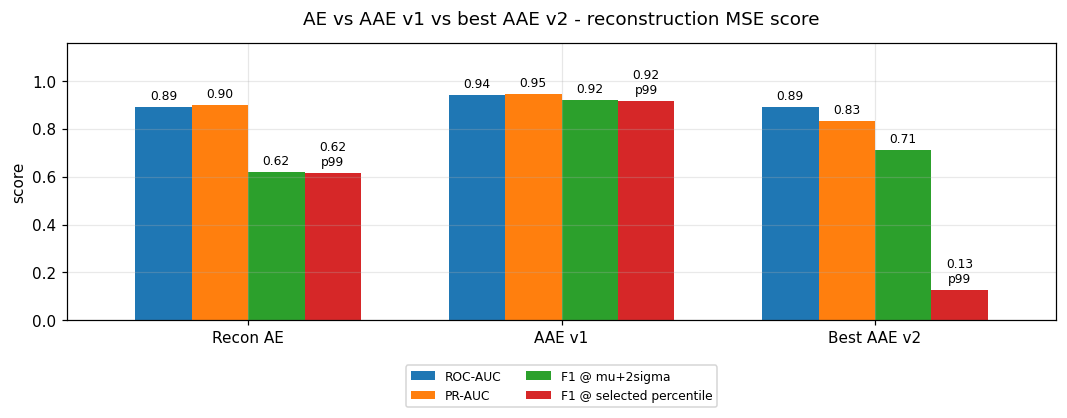

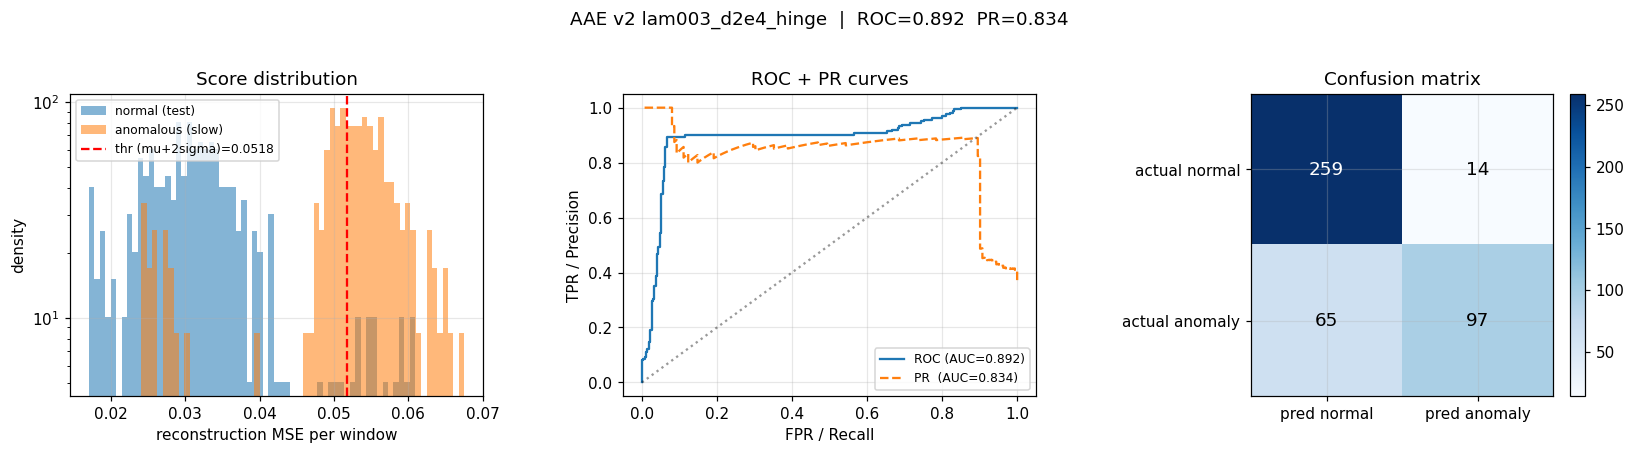


saved -> c:\Users\siava\Desktop\4th_Semester\ML-App\project-AM01\github_version\ML_APP_Anomaly_Detection\outputs\ae_compare\semi_supervised\compare_aae_v2_sweep.json

Best AAE v2 vs AAE v1:
  Delta ROC-AUC = -0.0492
  Delta PR-AUC  = -0.1139
  Delta F1 mu2  = -0.2099
  Delta F1 pct  = -0.7898


In [15]:
# ---------------- all sweep candidates ---------------------------------
print(f"{'variant':>24s} | {'lambda':>7s} | {'lr_D':>7s} | {'G loss':>7s} | "
      f"{'val PR':>6s} {'val ROC':>7s} | {'test ROC':>8s} {'test PR':>7s} {'test F1':>7s} | "
      f"{'P':>5s} {'R':>5s}")
print("-" * 121)
for run in sorted(aae_v2_runs,
                  key=lambda r: (r["result"]["selection"]["val_pr_auc"],
                                 r["result"]["selection"]["val_roc_auc"]),
                  reverse=True):
    cfg = run["cfg"]; res = run["result"]
    sel = res["selection"]
    op = res["operating_points"]["mu+2sigma"]
    print(f"{cfg['name']:>24s} | {cfg['lambda_adv']:7.3g} | {cfg['lr_D']:7.1e} | {cfg['g_loss']:>7s} | "
          f"{sel['val_pr_auc']:6.3f} {sel['val_roc_auc']:7.3f} | "
          f"{res['roc_auc']:8.3f} {res['pr_auc']:7.3f} {op['F1']:7.3f} | "
          f"{op['P']:5.3f} {op['R']:5.3f}")

# ---------------- compare AE, AAE v1, best AAE v2 ----------------------
if "best_percentile" not in recon_res:
    attach_percentile_selection(recon_res, recon_ss_val)
if "best_percentile" not in aae_res:
    attach_percentile_selection(aae_res, aae_ss_val)
if "best_percentile" not in aae_v2_best_res:
    attach_percentile_selection(aae_v2_best_res, best_run["scores"]["ss_val"], display_name="AAE v2")

results_aae_sweep = [recon_res, aae_res, aae_v2_best_res]

print("\nBest MSE-scored AAE v2 vs baselines")
print(f"{'model':>28s} | {'ROC-AUC':>8s} | {'PR-AUC':>7s} | "
      f"{'F1 mu2':>7s} {'F1 pct':>7s} | {'pct':>5s} | {'TP':>3s} {'FP':>3s} {'TN':>3s} {'FN':>3s}")
print("-" * 112)
for r in results_aae_sweep:
    op = r["operating_points"]["mu+2sigma"]
    pct = r["best_percentile"]
    print(f"{r['tag']:>28s} | {r['roc_auc']:8.4f} | {r['pr_auc']:7.4f} | "
          f"{op['F1']:7.3f} {pct['test_F1']:7.3f} | {pct['rule']:>5s} | "
          f"{pct['test_tp']:3d} {pct['test_fp']:3d} {pct['test_tn']:3d} {pct['test_fn']:3d}")

labels = ["Recon AE", "AAE v1", "Best AAE v2"]
roc = [r["roc_auc"] for r in results_aae_sweep]
pr = [r["pr_auc"] for r in results_aae_sweep]
f1_mu2 = [r["operating_points"]["mu+2sigma"]["F1"] for r in results_aae_sweep]
f1_pct = [r["best_percentile"]["test_F1"] for r in results_aae_sweep]
pct_rules = [r["best_percentile"]["rule"] for r in results_aae_sweep]

plot_metric_bars(
    labels, roc, pr, f1_mu2, f1_pct, pct_rules,
    title="AE vs AAE v1 vs best AAE v2 - reconstruction MSE score",
    figsize=(9.8, 4.6),
)

plot_diagnostics(aae_v2_best_res, score_label="reconstruction MSE per window")

# ---------------- save sweep summary -----------------------------------
summary_aae_v2_sweep = {
    "selection": "best validation PR-AUC, validation ROC-AUC tie-breaker on val_normal + slow_val",
    "fixed": {
        "generator": "ConvAE1D unchanged",
        "discriminator": "Discriminator1D unchanged",
        "inference_score": "reconstruction mean_MSE per window",
        "epochs_cap": AAE_V2_SWEEP_EPOCHS,
        "patience": AAE_V2_SWEEP_PATIENCE,
        "betas": list(AAE_V2_BETAS),
    },
    "sweep": [
        {
            "config": run["cfg"],
            "best_val_mse": run["best_val"],
            "checkpoint": run["checkpoint"],
            "selection_metrics": run["result"]["selection"],
            "metrics": compact_result(run["result"]),
        } for run in aae_v2_runs
    ],
    "best": {
        "config": aae_v2_best_cfg,
        "metrics": compact_result(aae_v2_best_res),
    },
    "baselines": {
        "Reconstruction AE": compact_result(recon_res),
        "AAE v1": compact_result(aae_res),
    },
}
with open(OUTPUT_DIR / "compare_aae_v2_sweep.json", "w", encoding="utf-8") as f:
    json.dump(summary_aae_v2_sweep, f, indent=2, default=float)
print("\nsaved ->", OUTPUT_DIR / "compare_aae_v2_sweep.json")

print("\nBest AAE v2 vs AAE v1:")
print(f"  Delta ROC-AUC = {aae_v2_best_res['roc_auc'] - aae_res['roc_auc']:+.4f}")
print(f"  Delta PR-AUC  = {aae_v2_best_res['pr_auc'] - aae_res['pr_auc']:+.4f}")
print(f"  Delta F1 mu2  = {aae_v2_best_res['operating_points']['mu+2sigma']['F1'] - aae_res['operating_points']['mu+2sigma']['F1']:+.4f}")
print(f"  Delta F1 pct  = {aae_v2_best_res['best_percentile']['test_F1'] - aae_res['best_percentile']['test_F1']:+.4f}")

## 10. Forecasting AAE - adversarial forecasting objective

This is a separate ablation from reconstruction AAE:

- Forecasting AE: input = first 64 timesteps, target = next 64 timesteps.
- Forecasting AAE: same forecasting generator, plus a discriminator that judges real future windows vs generated future windows.
- Inference score stays forecast `mean_MSE`, exactly like Forecasting AE.

So this section asks: does adversarial regularization help the forecasting objective?

[Forecasting AAE] G params=48,277   D params=53,473   lambda_adv=0.01
  [Forecasting AAE] ep 001 | MSE tr=0.17102 val=0.11538 | L_D=2.327 L_G_adv=-0.289 | D(real)=+0.30 D(fake)=+0.61 *
  [Forecasting AAE] ep 002 | MSE tr=0.10022 val=0.10710 | L_D=2.330 L_G_adv=-0.328 | D(real)=+0.19 D(fake)=+0.51 *
  [Forecasting AAE] ep 003 | MSE tr=0.07855 val=0.09072 | L_D=2.233 L_G_adv=-0.160 | D(real)=+0.04 D(fake)=+0.27 *
  [Forecasting AAE] ep 004 | MSE tr=0.06328 val=0.08666 | L_D=2.031 L_G_adv=+0.098 | D(real)=-0.07 D(fake)=-0.04 *
  [Forecasting AAE] ep 005 | MSE tr=0.05551 val=0.07484 | L_D=1.820 L_G_adv=+0.339 | D(real)=-0.11 D(fake)=-0.30 *
  [Forecasting AAE] ep 006 | MSE tr=0.04896 val=0.06762 | L_D=1.745 L_G_adv=+0.460 | D(real)=-0.16 D(fake)=-0.42 *
  [Forecasting AAE] ep 007 | MSE tr=0.04699 val=0.06448 | L_D=1.593 L_G_adv=+0.574 | D(real)=-0.12 D(fake)=-0.54 *
  [Forecasting AAE] ep 008 | MSE tr=0.04752 val=0.06795 | L_D=1.421 L_G_adv=+0.635 | D(real)=+0.03 D(fake)=-0.57
  [Forecasti

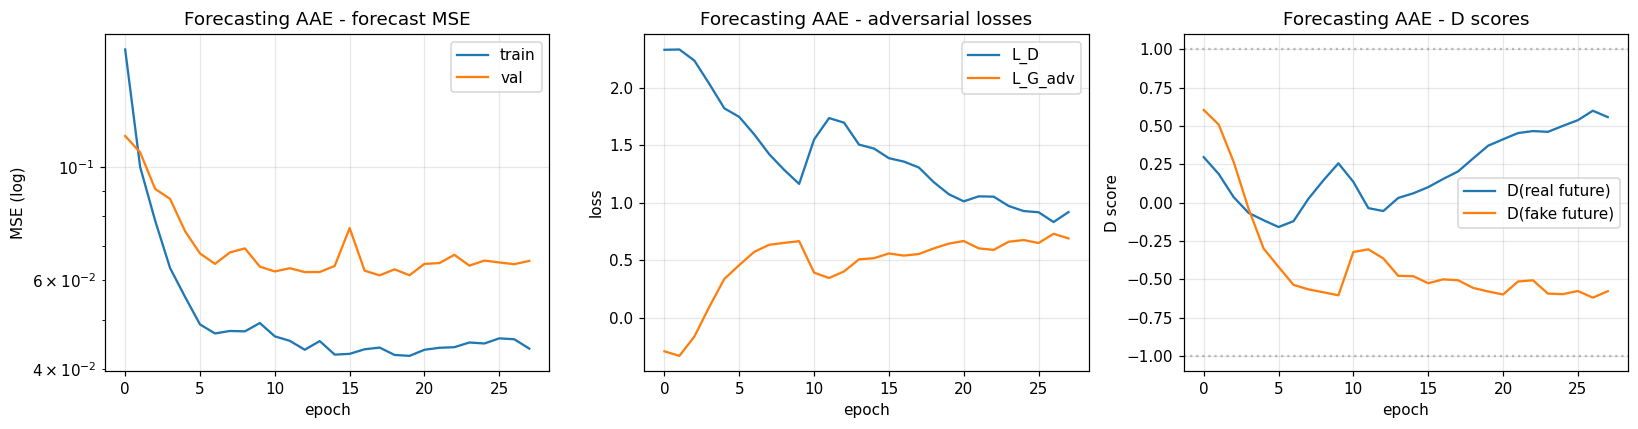

In [16]:
# --- Forecasting AAE hyperparameters -----------------------------------
# Same generator architecture as Forecasting AE; discriminator sees 64-step future windows.
LR_G_FAAE = 1e-3
LR_D_FAAE = 1e-4
LAMBDA_ADV_FAAE = 0.01
BETAS_FAAE = (0.5, 0.999)


def train_forecast_aae(train_loader, val_loader, *, tag="Forecasting AAE", seed=42):
    """Train G(first half) -> next half, with D judging real vs generated future windows."""
    torch.manual_seed(seed); np.random.seed(seed)
    G = ConvAE1D(n_features=n_features, enc_channels=ENC_CHANNELS).to(DEVICE)
    D = Discriminator1D(n_features=n_features, input_len=FORECAST_HALF).to(DEVICE)

    opt_G = torch.optim.Adam(G.parameters(), lr=LR_G_FAAE, betas=BETAS_FAAE)
    opt_D = torch.optim.Adam(D.parameters(), lr=LR_D_FAAE, betas=BETAS_FAAE)
    mse = nn.MSELoss()

    nG = sum(p.numel() for p in G.parameters())
    nD = sum(p.numel() for p in D.parameters())
    print(f"[{tag}] G params={nG:,}   D params={nD:,}   lambda_adv={LAMBDA_ADV_FAAE}")

    hist = {"train_mse": [], "val_mse": [], "loss_D": [], "loss_G_adv": [],
            "d_real": [], "d_fake": []}
    best_val, best_state, remaining = float("inf"), None, PATIENCE

    for epoch in range(1, EPOCHS + 1):
        G.train(); D.train()
        sums = {k: 0.0 for k in ("mse", "lD", "lGadv", "dreal", "dfake")}
        n_seen = 0

        for x_past, x_future in train_loader:
            x_past = x_past.to(DEVICE, non_blocking=True)
            x_future = x_future.to(DEVICE, non_blocking=True)

            # D step: real future windows vs generated future windows.
            opt_D.zero_grad(set_to_none=True)
            with torch.no_grad():
                x_fake_d = G(x_past)
            d_real = D(x_future)
            d_fake = D(x_fake_d)
            loss_D = hinge_loss_D(d_real, d_fake)
            loss_D.backward()
            opt_D.step()

            # G step: forecast MSE + adversarial future-window realism.
            opt_G.zero_grad(set_to_none=True)
            x_fake = G(x_past)
            mse_loss = mse(x_fake, x_future)
            adv_loss_G = hinge_loss_G(D(x_fake))
            loss_G = mse_loss + LAMBDA_ADV_FAAE * adv_loss_G
            loss_G.backward()
            nn.utils.clip_grad_norm_(G.parameters(), GRAD_CLIP)
            opt_G.step()

            bs = x_past.size(0); n_seen += bs
            sums["mse"] += mse_loss.item() * bs
            sums["lD"] += loss_D.item() * bs
            sums["lGadv"] += adv_loss_G.item() * bs
            sums["dreal"] += d_real.mean().item() * bs
            sums["dfake"] += d_fake.mean().item() * bs

        tr_mse = sums["mse"] / n_seen
        tr_lD = sums["lD"] / n_seen
        tr_lGadv = sums["lGadv"] / n_seen
        tr_dr = sums["dreal"] / n_seen
        tr_df = sums["dfake"] / n_seen

        G.eval()
        with torch.no_grad():
            tot, n = 0.0, 0
            for xv_past, xv_future in val_loader:
                xv_past = xv_past.to(DEVICE, non_blocking=True)
                xv_future = xv_future.to(DEVICE, non_blocking=True)
                tot += mse(G(xv_past), xv_future).item() * xv_past.size(0)
                n += xv_past.size(0)
            va_mse = tot / max(n, 1)

        hist["train_mse"].append(tr_mse); hist["val_mse"].append(va_mse)
        hist["loss_D"].append(tr_lD); hist["loss_G_adv"].append(tr_lGadv)
        hist["d_real"].append(tr_dr); hist["d_fake"].append(tr_df)

        improved = va_mse < best_val - 1e-6
        if improved:
            best_val = va_mse
            best_state = {"G": copy.deepcopy(G.state_dict()), "D": copy.deepcopy(D.state_dict())}
            remaining = PATIENCE
        print(f"  [{tag}] ep {epoch:03d} | MSE tr={tr_mse:.5f} val={va_mse:.5f} | "
              f"L_D={tr_lD:.3f} L_G_adv={tr_lGadv:+.3f} | "
              f"D(real)={tr_dr:+.2f} D(fake)={tr_df:+.2f}{' *' if improved else ''}")

        if not improved:
            remaining -= 1
            if remaining <= 0:
                print(f"  [{tag}] Early stop at epoch {epoch} (best val MSE {best_val:.6f})")
                break

    G.load_state_dict(best_state["G"])
    D.load_state_dict(best_state["D"])
    return G, D, hist, best_val


fc_aae_G, fc_aae_D, fc_aae_hist, fc_aae_best_val = train_forecast_aae(
    forecast_train_loader, forecast_val_loader, tag="Forecasting AAE")

torch.save({"G_state": fc_aae_G.state_dict(), "D_state": fc_aae_D.state_dict(),
            "history": fc_aae_hist,
            "config": {"window_len": WINDOW_LEN,
                       "forecast_half": FORECAST_HALF,
                       "objective": "adversarial forecasting",
                       "enc_channels": list(ENC_CHANNELS),
                       "batch_size": BATCH_SIZE,
                       "lr_G": LR_G_FAAE, "lr_D": LR_D_FAAE,
                       "lambda_adv": LAMBDA_ADV_FAAE,
                       "betas": list(BETAS_FAAE),
                       "epochs_run": len(fc_aae_hist["train_mse"]),
                       "best_val_mse": fc_aae_best_val}},
           OUTPUT_DIR / "forecast_aae.pt")
print("saved ->", OUTPUT_DIR / "forecast_aae.pt")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ax = axes[0]
ax.plot(fc_aae_hist["train_mse"], label="train"); ax.plot(fc_aae_hist["val_mse"], label="val")
ax.set_yscale("log"); ax.set_xlabel("epoch"); ax.set_ylabel("MSE (log)")
ax.set_title("Forecasting AAE - forecast MSE"); ax.legend()

ax = axes[1]
ax.plot(fc_aae_hist["loss_D"], label="L_D")
ax.plot(fc_aae_hist["loss_G_adv"], label="L_G_adv")
ax.set_xlabel("epoch"); ax.set_ylabel("loss")
ax.set_title("Forecasting AAE - adversarial losses"); ax.legend()

ax = axes[2]
ax.plot(fc_aae_hist["d_real"], label="D(real future)")
ax.plot(fc_aae_hist["d_fake"], label="D(fake future)")
ax.axhline(+1, color="grey", linestyle=":", alpha=0.5)
ax.axhline(-1, color="grey", linestyle=":", alpha=0.5)
ax.set_xlabel("epoch"); ax.set_ylabel("D score")
ax.set_title("Forecasting AAE - D scores"); ax.legend()

plt.tight_layout(); plt.show()

### 10.1 Evaluate Forecasting AAE

val_normal   n= 273  mean=0.06121  p99=0.12175
test_normal  n= 273  mean=0.05036  p99=0.06999
slow_val     n= 162  mean=0.04774  p99=0.07539
slow_test    n= 162  mean=0.08109  p99=0.10700

[Forecasting AAE]  ROC-AUC = 0.9751   PR-AUC = 0.9526
[Forecasting AAE]  Threshold (val_normal mu+2sigma) = 0.090862

               pred normal | pred anomaly
actual normal        272            1
actual anomaly       131           31

              precision    recall  f1-score   support

      normal      0.675     0.996     0.805       273
     anomaly      0.969     0.191     0.320       162

    accuracy                          0.697       435
   macro avg      0.822     0.594     0.562       435
weighted avg      0.784     0.697     0.624       435



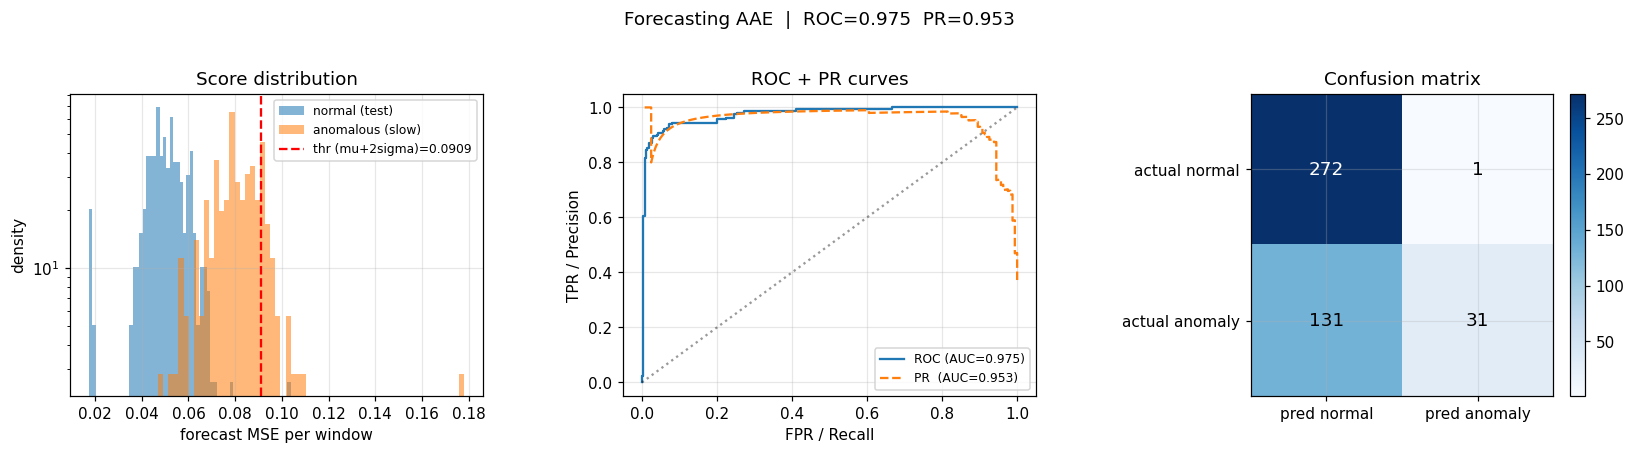

In [17]:
# Forecasting AAE score = mean MSE between generated future and true future.
fc_aae_sv = score_mean_mse(fc_aae_G, X_val_in,  X_val_tg)
fc_aae_st = score_mean_mse(fc_aae_G, X_test_in, X_test_tg)
fc_aae_ss_val = score_mean_mse(fc_aae_G, X_slow_val_in, X_slow_val_tg)
fc_aae_ss = score_mean_mse(fc_aae_G, X_slow_in, X_slow_tg)  # slow-test only

print(f"val_normal   n={fc_aae_sv.size:4d}  mean={fc_aae_sv.mean():.5f}  p99={np.percentile(fc_aae_sv, 99):.5f}")
print(f"test_normal  n={fc_aae_st.size:4d}  mean={fc_aae_st.mean():.5f}  p99={np.percentile(fc_aae_st, 99):.5f}")
print(f"slow_val     n={fc_aae_ss_val.size:4d}  mean={fc_aae_ss_val.mean():.5f}  p99={np.percentile(fc_aae_ss_val, 99):.5f}")
print(f"slow_test    n={fc_aae_ss.size:4d}  mean={fc_aae_ss.mean():.5f}  p99={np.percentile(fc_aae_ss, 99):.5f}")
print()

fc_aae_res = evaluate_scores(fc_aae_sv, fc_aae_st, fc_aae_ss, tag="Forecasting AAE")
attach_percentile_selection(fc_aae_res, fc_aae_ss_val)
print_headline(fc_aae_res)
plot_diagnostics(fc_aae_res, score_label="forecast MSE per window")


### 10.2 Forecasting AE vs Forecasting AAE

                 model |  ROC-AUC |  PR-AUC |  F1 mu2  F1 pct |   pct |  TP  FP  TN  FN
----------------------------------------------------------------------------------------------------------
        Forecasting AE |   0.9639 |  0.9595 |   0.915   0.805 |   p80 | 153  65 208   9
       Forecasting AAE |   0.9751 |  0.9526 |   0.320   0.908 |   p80 | 138   4 269  24


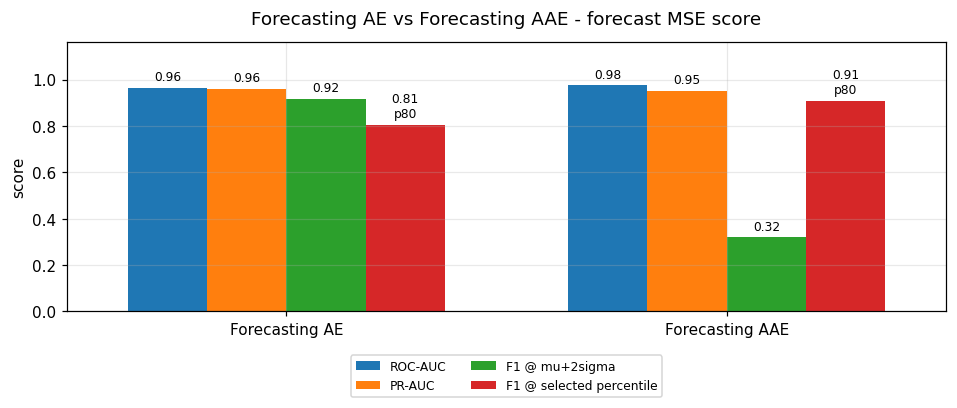


saved -> c:\Users\siava\Desktop\4th_Semester\ML-App\project-AM01\github_version\ML_APP_Anomaly_Detection\outputs\ae_compare\semi_supervised\compare_forecast_aae.json

Forecasting AAE vs Forecasting AE:
  Delta ROC-AUC = +0.0112
  Delta PR-AUC  = -0.0069
  Delta F1 mu2  = -0.5958
  Delta F1 pct  = +0.1026


In [18]:
forecast_adv_results = [fc_res, fc_aae_res]

print(f"{'model':>22s} | {'ROC-AUC':>8s} | {'PR-AUC':>7s} | "
      f"{'F1 mu2':>7s} {'F1 pct':>7s} | {'pct':>5s} | {'TP':>3s} {'FP':>3s} {'TN':>3s} {'FN':>3s}")
print("-" * 106)
for r in forecast_adv_results:
    op = r["operating_points"]["mu+2sigma"]
    pct = r["best_percentile"]
    print(f"{r['tag']:>22s} | {r['roc_auc']:8.4f} | {r['pr_auc']:7.4f} | "
          f"{op['F1']:7.3f} {pct['test_F1']:7.3f} | {pct['rule']:>5s} | "
          f"{pct['test_tp']:3d} {pct['test_fp']:3d} {pct['test_tn']:3d} {pct['test_fn']:3d}")

labels = ["Forecasting AE", "Forecasting AAE"]
roc = [r["roc_auc"] for r in forecast_adv_results]
pr = [r["pr_auc"] for r in forecast_adv_results]
f1_mu2 = [r["operating_points"]["mu+2sigma"]["F1"] for r in forecast_adv_results]
f1_pct = [r["best_percentile"]["test_F1"] for r in forecast_adv_results]
pct_rules = [r["best_percentile"]["rule"] for r in forecast_adv_results]

plot_metric_bars(
    labels, roc, pr, f1_mu2, f1_pct, pct_rules,
    title="Forecasting AE vs Forecasting AAE - forecast MSE score",
    figsize=(8.8, 4.5),
)

summary_forecast_aae = {
    "config": {
        "window_len": WINDOW_LEN,
        "forecast_half": FORECAST_HALF,
        "enc_channels": list(ENC_CHANNELS),
        "batch_size": BATCH_SIZE,
        "epochs_cap": EPOCHS,
        "patience": PATIENCE,
        "fc_ae_lr": LEARNING_RATE,
        "fc_aae_lr_G": LR_G_FAAE,
        "fc_aae_lr_D": LR_D_FAAE,
        "fc_aae_lambda_adv": LAMBDA_ADV_FAAE,
        "inference_score": "forecast mean_MSE per window",
        "slow_split": "first SLOW_VAL_FRAC slow windows for threshold validation; remaining slow windows for final test",
        "slow_val_frac": SLOW_VAL_FRAC,
        "n_slow_val": int(len(W_slow_val)),
        "n_test_normal": int(fc_st.size),
        "n_test_anomaly": int(fc_ss.size),
    },
    "models": {
        r["tag"]: {
            "roc_auc": r["roc_auc"],
            "pr_auc": r["pr_auc"],
            "operating_points": r["operating_points"],
            "best_percentile": r["best_percentile"],
        } for r in forecast_adv_results
    },
}
with open(OUTPUT_DIR / "compare_forecast_aae.json", "w", encoding="utf-8") as f:
    json.dump(summary_forecast_aae, f, indent=2, default=float)
print("\nsaved ->", OUTPUT_DIR / "compare_forecast_aae.json")

print("\nForecasting AAE vs Forecasting AE:")
print(f"  Delta ROC-AUC = {fc_aae_res['roc_auc'] - fc_res['roc_auc']:+.4f}")
print(f"  Delta PR-AUC  = {fc_aae_res['pr_auc'] - fc_res['pr_auc']:+.4f}")
print(f"  Delta F1 mu2  = {fc_aae_res['operating_points']['mu+2sigma']['F1'] - fc_res['operating_points']['mu+2sigma']['F1']:+.4f}")
print(f"  Delta F1 pct  = {fc_aae_res['best_percentile']['test_F1'] - fc_res['best_percentile']['test_F1']:+.4f}")

### 10.3 Unified percentile threshold sensitivity

This cell applies the same semi-supervised percentile-threshold rule to every model. Candidate percentile thresholds are generated from `val_normal` scores, the best percentile is selected using `val_normal + slow_val`, and that frozen threshold is then evaluated on `test_normal + slow_test`.


In [19]:
threshold_model_specs = [
    ("Reconstruction AE", recon_res, recon_ss_val),
    ("Forecasting AE", fc_res, fc_ss_val),
    ("AAE", aae_res, aae_ss_val),
    ("AAE v2", aae_v2_best_res, best_run["scores"]["ss_val"]),
    ("Forecasting AAE", fc_aae_res, fc_aae_ss_val),
]

semi_supervised_threshold_rows = []
semi_supervised_threshold_best = {}
for tag, res, ss_val in threshold_model_specs:
    attach_percentile_selection(res, ss_val, display_name=tag)
    rows = res["percentile_rows"]
    best = res["best_percentile"]
    semi_supervised_threshold_rows.extend(rows)
    semi_supervised_threshold_best[tag] = best

# Backward-compatible aliases for the forecasting plot below.
forecast_threshold_rows = [
    r for r in semi_supervised_threshold_rows
    if r["model"] in {"Forecasting AE", "Forecasting AAE"}
]
forecast_threshold_best = {
    "Forecasting AE": semi_supervised_threshold_best["Forecasting AE"],
    "Forecasting AAE": semi_supervised_threshold_best["Forecasting AAE"],
}

print("Semi-supervised percentile thresholds: choose by validation F1, then freeze for test")
for tag, _, _ in threshold_model_specs:
    print(f"\n{tag}")
    print(f"{'rule':>6s} | {'thr':>9s} | {'val F1':>6s} {'val P':>5s} {'val R':>5s} | "
          f"{'test F1':>7s} {'test P':>6s} {'test R':>6s} | {'TP':>3s} {'FP':>3s} {'TN':>3s} {'FN':>3s}")
    print("-" * 88)
    for row in [r for r in semi_supervised_threshold_rows if r["model"] == tag]:
        star = " *" if row is semi_supervised_threshold_best[tag] else "  "
        print(f"{row['rule']:>6s} | {row['thr']:9.5f} | "
              f"{row['val_F1']:6.3f} {row['val_P']:5.3f} {row['val_R']:5.3f} | "
              f"{row['test_F1']:7.3f} {row['test_P']:6.3f} {row['test_R']:6.3f} | "
              f"{row['test_tp']:3d} {row['test_fp']:3d} {row['test_tn']:3d} {row['test_fn']:3d}{star}")

    best = semi_supervised_threshold_best[tag]
    print(f"Best validation percentile for {tag}: {best['rule']} "
          f"val_F1={best['val_F1']:.3f} -> test_F1={best['test_F1']:.3f}, "
          f"thr={best['thr']:.5f}")

threshold_f1_summary = {}
for tag, res, _ in threshold_model_specs:
    best = semi_supervised_threshold_best[tag]
    threshold_f1_summary[tag] = {
        "f1_mu2sigma": res["operating_points"]["mu+2sigma"]["F1"],
        "best_percentile": best["rule"],
        "best_val_f1": best["val_F1"],
        "test_f1_at_best_percentile": best["test_F1"],
    }

print("\nF1 summary used in the final plots")
for tag, vals in threshold_f1_summary.items():
    print(f"{tag}: F1@mu+2sigma={vals['f1_mu2sigma']:.3f} | "
          f"best_percentile={vals['best_percentile']} val_F1={vals['best_val_f1']:.3f} "
          f"-> test_F1={vals['test_f1_at_best_percentile']:.3f}")

summary_threshold = {
    "note": "Percentile thresholds are derived from val_normal scores; the best percentile is selected on val_normal + slow_val and then frozen for test_normal + slow_test.",
    "percentile_candidates": list(PERCENTILE_CANDIDATES),
    "primary_metrics": {
        tag: {"roc_auc": res["roc_auc"], "pr_auc": res["pr_auc"]}
        for tag, res, _ in threshold_model_specs
    },
    "f1_summary": threshold_f1_summary,
    "rows": semi_supervised_threshold_rows,
    "best_by_val_f1": semi_supervised_threshold_best,
}
threshold_path = OUTPUT_DIR / "threshold_sensitivity.json"
legacy_forecast_path = OUTPUT_DIR / "forecast_threshold_sensitivity.json"
with open(threshold_path, "w", encoding="utf-8") as f:
    json.dump(summary_threshold, f, indent=2, default=float)
with open(legacy_forecast_path, "w", encoding="utf-8") as f:
    json.dump(summary_threshold, f, indent=2, default=float)
print("\nsaved ->", threshold_path)
print("saved compatibility copy ->", legacy_forecast_path)


Semi-supervised percentile thresholds: choose by validation F1, then freeze for test

Reconstruction AE
  rule |       thr | val F1 val P val R | test F1 test P test R |  TP  FP  TN  FN
----------------------------------------------------------------------------------------
   p80 |   0.02553 |  0.000 0.000 0.000 |   0.859  0.836  0.883 | 143  28 245  19  
   p85 |   0.03014 |  0.000 0.000 0.000 |   0.812  0.908  0.735 | 119  12 261  43  
   p90 |   0.03150 |  0.000 0.000 0.000 |   0.749  0.952  0.617 | 100   5 268  62  
   p95 |   0.03307 |  0.000 0.000 0.000 |   0.656  0.976  0.494 |  80   2 271  82  
   p97 |   0.03351 |  0.000 0.000 0.000 |   0.627  1.000  0.457 |  74   0 273  88  
   p99 |   0.03440 |  0.000 0.000 0.000 |   0.615  1.000  0.444 |  72   0 273  90 *
Best validation percentile for Reconstruction AE: p99 val_F1=0.000 -> test_F1=0.615, thr=0.03440

Forecasting AE
  rule |       thr | val F1 val P val R | test F1 test P test R |  TP  FP  TN  FN
--------------------------

### 10.4 Final forecasting comparison plot

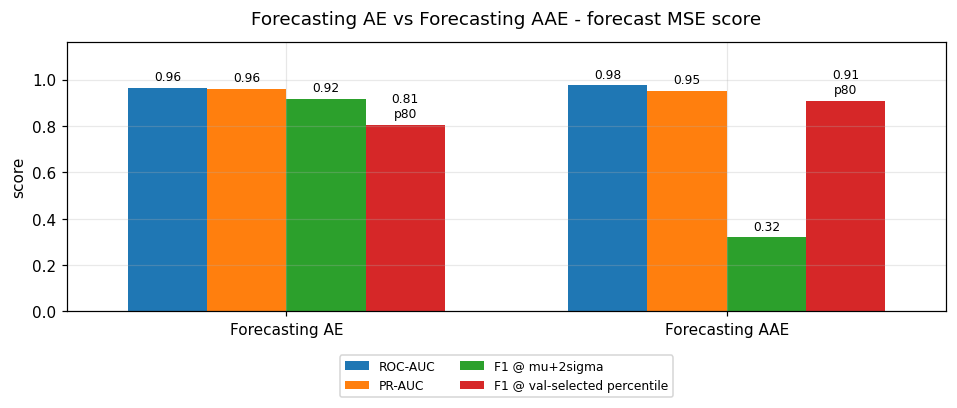

(<Figure size 968x495 with 1 Axes>,
 <Axes: title={'center': 'Forecasting AE vs Forecasting AAE - forecast MSE score'}, ylabel='score'>)

In [20]:
# Final headline plot: Forecasting AE vs Forecasting AAE.
# Shows threshold-free metrics plus two F1 operating points for each model.
forecast_adv_results = [fc_res, fc_aae_res]
labels = ["Forecasting AE", "Forecasting AAE"]
roc = [r["roc_auc"] for r in forecast_adv_results]
pr = [r["pr_auc"] for r in forecast_adv_results]
f1_mu2 = [r["operating_points"]["mu+2sigma"]["F1"] for r in forecast_adv_results]

# Requires the previous unified threshold-sensitivity cell. Recompute if needed.
if "forecast_threshold_best" not in globals():
    forecast_threshold_rows = []
    forecast_threshold_best = {}
    for tag, sv, ss_val, st, ss_test in [
        ("Forecasting AE", fc_sv, fc_ss_val, fc_st, fc_ss),
        ("Forecasting AAE", fc_aae_sv, fc_aae_ss_val, fc_aae_st, fc_aae_ss),
    ]:
        rows, best = select_percentile_threshold_from_val(sv, ss_val, st, ss_test, tag=tag)
        forecast_threshold_rows.extend(rows)
        forecast_threshold_best[tag] = best

f1_val_selected = [forecast_threshold_best[label]["test_F1"] for label in labels]
best_rules = [forecast_threshold_best[label]["rule"] for label in labels]

plot_metric_bars(
    labels, roc, pr, f1_mu2, f1_val_selected, best_rules,
    title="Forecasting AE vs Forecasting AAE - forecast MSE score",
    selected_label="F1 @ val-selected percentile",
    figsize=(8.8, 4.5),
)


## 11. Final summary - AE/AAE and Forecasting AE/AAE

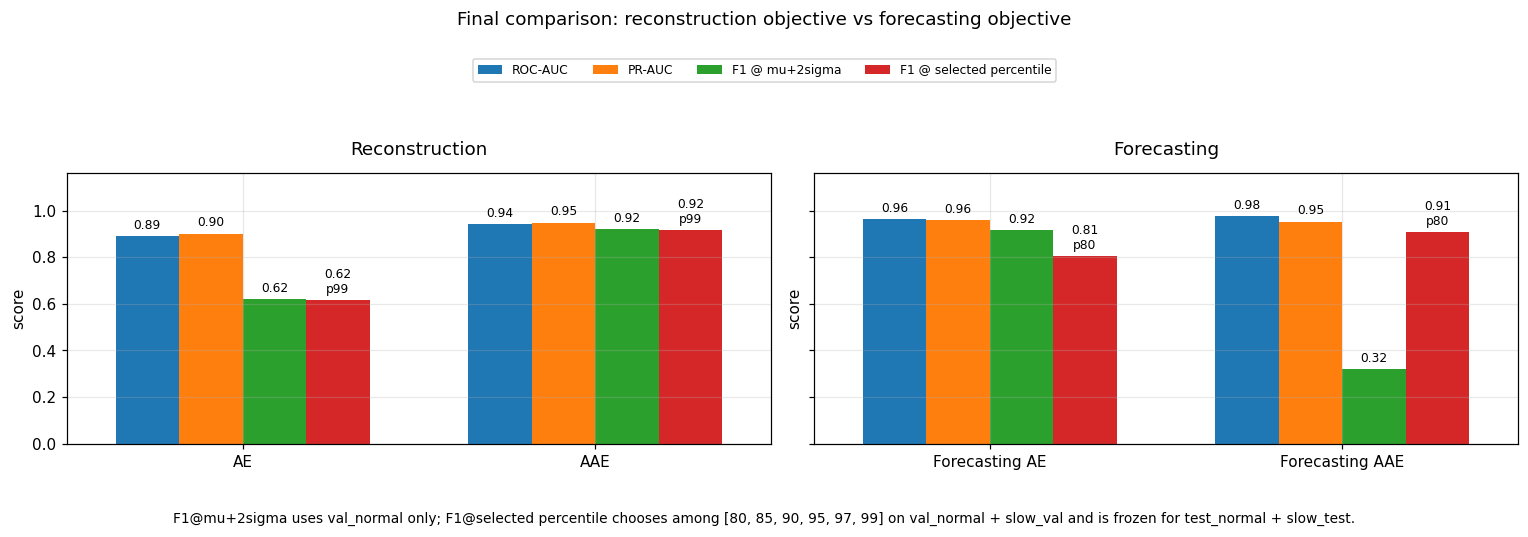

Final comparison table
F1 threshold note: F1@mu+2sigma uses val_normal only; F1@selected percentile chooses among [80, 85, 90, 95, 97, 99] on val_normal + slow_val and is frozen for test_normal + slow_test.
          group |            model |    ROC     PR  F1 mu2  F1 pct |   pct
----------------------------------------------------------------------------------
 Reconstruction |               AE |  0.891  0.900   0.621   0.615 |   p99
 Reconstruction |              AAE |  0.941  0.948   0.921   0.917 |   p99
    Forecasting |   Forecasting AE |  0.964  0.960   0.915   0.805 |   p80
    Forecasting |  Forecasting AAE |  0.975  0.953   0.320   0.908 |   p80


In [21]:
# Final summary plot across both clean ablations.
# Reconstruction models use reconstruction MSE; forecasting models use forecast MSE.
if "semi_supervised_threshold_best" not in globals():
    raise RuntimeError("Run the unified percentile threshold sensitivity cell first.")

final_groups = {
    "Reconstruction": [
        ("AE", recon_res, "Reconstruction AE"),
        ("AAE", aae_res, "AAE"),
    ],
    "Forecasting": [
        ("Forecasting AE", fc_res, "Forecasting AE"),
        ("Forecasting AAE", fc_aae_res, "Forecasting AAE"),
    ],
}

threshold_note = (
    "F1@mu+2sigma uses val_normal only; F1@selected percentile chooses among "
    f"{list(PERCENTILE_CANDIDATES)} on val_normal + slow_val and is frozen for test_normal + slow_test."
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)

for ax, (group_name, entries) in zip(axes, final_groups.items()):
    labels = [e[0] for e in entries]
    roc = [e[1]["roc_auc"] for e in entries]
    pr = [e[1]["pr_auc"] for e in entries]
    f1_mu2 = [e[1]["operating_points"]["mu+2sigma"]["F1"] for e in entries]
    f1_pct = [semi_supervised_threshold_best[e[2]]["test_F1"] for e in entries]
    pct_rules = [semi_supervised_threshold_best[e[2]]["rule"] for e in entries]
    plot_metric_bars(
        labels, roc, pr, f1_mu2, f1_pct, pct_rules,
        title=group_name,
        ax=ax,
        legend=False,
        show=False,
    )

axes[0].set_ylabel("score")
handles, legend_labels = axes[0].get_legend_handles_labels()
fig.suptitle("Final comparison: reconstruction objective vs forecasting objective", y=0.99)
fig.legend(handles, legend_labels, loc="upper center", bbox_to_anchor=(0.5, 0.91),
           ncol=4, fontsize=8, frameon=True)
fig.text(0.5, 0.02, threshold_note, ha="center", fontsize=9)
plt.tight_layout(rect=(0, 0.09, 1, 0.84)); plt.show()

print("Final comparison table")
print("F1 threshold note:", threshold_note)
print(f"{'group':>15s} | {'model':>16s} | {'ROC':>6s} {'PR':>6s} {'F1 mu2':>7s} {'F1 pct':>7s} | {'pct':>5s}")
print("-" * 82)
for group_name, entries in final_groups.items():
    for model_name, res, pct_key in entries:
        best = semi_supervised_threshold_best[pct_key]
        print(f"{group_name:>15s} | {model_name:>16s} | "
              f"{res['roc_auc']:6.3f} {res['pr_auc']:6.3f} "
              f"{res['operating_points']['mu+2sigma']['F1']:7.3f} {best['test_F1']:7.3f} | "
              f"{best['rule']:>5s}")
